In [2]:
# ========== 导入所需库 ==========
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑，最常用
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题
import seaborn as sns

In [3]:
cd D:\4080\log\4.22-28

D:\4080\log\4.15-4.21


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
# ========== 导入聚合好的月度数据 ==========
print("="*60)
print("导入聚合好的月度数据")
print("="*60)

# 读取parquet文件
df_monthly = pd.read_parquet(r"monthly_aggregated_filled.parquet")

# 数据检查
print(f"数据形状: {df_monthly.shape[0]:,}行, {df_monthly.shape[1]}列")
print(f"\n数据列: {list(df_monthly.columns)}")
print(f"\n数据类型:")
print(df_monthly.dtypes)

print(f"\n数据前5行:")
print(df_monthly.head())

print(f"\n数据统计摘要:")
print(df_monthly.describe())

# 检查关键列是否存在
required_cols = ['ref_branch_code', 'material_nature_sum_desc', 'month', 'monthly_sales']
missing_cols = [col for col in required_cols if col not in df_monthly.columns]
if missing_cols:
    print(f"\n⚠️ 警告: 缺少以下必要列: {missing_cols}")
else:
    print(f"\n✅ 所有必要列都存在")

# 检查月份范围
print(f"\n月份范围: {df_monthly['month'].min()} 到 {df_monthly['month'].max()}")

# 检查组合数量
n_combos = df_monthly.groupby(['ref_branch_code', 'material_nature_sum_desc']).ngroups
print(f"总组合数: {n_combos:,}")


导入聚合好的月度数据
数据形状: 499,318行, 5列

数据列: ['ref_branch_code', 'material_nature_sum_desc', 'month', 'monthly_sales', 'price']

数据类型:
ref_branch_code                     object
material_nature_sum_desc            object
month                       datetime64[us]
monthly_sales                      float64
price                              float64
dtype: object

数据前5行:
  ref_branch_code material_nature_sum_desc      month  monthly_sales  \
0         CAT_008                  CAT_001 2023-01-01     256468.426   
1         CAT_008                  CAT_001 2023-02-01     230430.495   
2         CAT_008                  CAT_001 2023-03-01     114700.734   
3         CAT_008                  CAT_001 2023-04-01     188948.217   
4         CAT_008                  CAT_001 2023-05-01     253250.105   

        price  
0  460.994231  
1  455.273077  
2  470.900000  
3  491.029545  
4  495.918333  

数据统计摘要:
                            month  monthly_sales          price
count                      499318  

In [5]:
# 检查每个组合的零值比例
zero_ratio = (df_monthly['monthly_sales'] == 0).groupby(
    [df_monthly['ref_branch_code'], df_monthly['material_nature_sum_desc']]
).mean()
print(zero_ratio.describe())

count    9288.000000
mean        0.002147
std         0.023031
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: monthly_sales, dtype: float64


In [6]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*60)
print("🚀 启动基于【STL残差与综合加权打分】的新版智能分群")
print("="*60)

# 假设您的原始汇总之表为 df 
# （请确保 df 中包含 ref_branch_code, material_nature_sum_desc, month, monthly_sales）
df = pd.read_parquet("monthly_aggregated_filled.parquet")
df['month'] = pd.to_datetime(df['month'])

# ==========================================
# 1. 计算时间跨度，区分长短时序
# ==========================================
def calc_span(group):
    months = group['month'].sort_values()
    if len(months) < 2:
        return 1
    start, end = months.iloc[0], months.iloc[-1]
    return (end.year - start.year) * 12 + (end.month - start.month) + 1

print("正在评估时间跨度...")
spans = df.groupby(['ref_branch_code', 'material_nature_sum_desc']).apply(calc_span)
long_term_mask = spans >= 24

long_term_combos = spans[long_term_mask].index.tolist()
short_term_combos = spans[~long_term_mask].index.tolist()

print(f"总组合数: {len(spans)}")
print(f"  --> 长时序组合数 (>=24个月): {len(long_term_combos)}")
print(f"  --> 短时序组合数 (<24个月): {len(short_term_combos)}")

# ==========================================
# 2. 长时序 STL 特征提取
# ==========================================
print("\n正在对长时序进行 STL 分解与特征提取 (这可能需要几分钟)...")
df_long = df.set_index(['ref_branch_code', 'material_nature_sum_desc']).loc[long_term_combos].reset_index()

def compute_cv_stl_features(sales):
    """计算CV、季节强度、残差CV"""
    sales = np.asarray(sales, dtype=float)
    if np.std(sales) < 1e-8:
        cv = 0.0 if np.mean(sales) > 0 else 100.0
        return cv, 0.0, 100.0  # 季节强度0，残差CV大
    
    mean_s = np.mean(sales)
    cv = np.std(sales) / mean_s if mean_s > 1e-6 else 100.0
    
    try:
        stl = STL(sales, period=12, robust=True).fit()
        var_seasonal = np.var(stl.seasonal)
        var_resid = np.var(stl.resid)
        seasonal_strength = 1 - var_resid / (var_seasonal + var_resid + 1e-8)
        cv_resid = np.std(stl.resid) / (mean_s + 1e-8)
    except Exception as e:
        seasonal_strength = 0.0
        cv_resid = 100.0
    return cv, seasonal_strength, cv_resid

features = []
for (branch, material), group in df_long.groupby(['ref_branch_code', 'material_nature_sum_desc']):
    group = group.sort_values('month')
    sales = group['monthly_sales'].values
    
    cv, Fs, cv_resid = compute_cv_stl_features(sales)
    features.append({
        'ref_branch_code': branch,
        'material_nature_sum_desc': material,
        'CV': cv,
        'seasonal_strength': Fs,
        'residual_cv': cv_resid,
        'length': len(sales)
    })

df_feat = pd.DataFrame(features)

# ==========================================
# 3. 极值截断与百分位加权打分
# ==========================================
# 对异常值做截断（防止极端值影响百分位排名）
df_feat['CV'] = df_feat['CV'].clip(upper=df_feat['CV'].quantile(0.99))
df_feat['residual_cv'] = df_feat['residual_cv'].clip(upper=df_feat['residual_cv'].quantile(0.99))

# 计算百分位排名
df_feat['CV_pct'] = df_feat['CV'].rank(pct=True)
df_feat['Fs_pct'] = df_feat['seasonal_strength'].rank(pct=True)
df_feat['ResCV_pct'] = df_feat['residual_cv'].rank(pct=True)

# 权重公式：CV和残差是负向指标（越小越好所以用 1 - pct），季节性是正向指标
w_cv, w_fs, w_res = 0.4, 0.4, 0.2
df_feat['score'] = (w_cv * (1 - df_feat['CV_pct']) +
                    w_fs * df_feat['Fs_pct'] +
                    w_res * (1 - df_feat['ResCV_pct'])) * 100

# ==========================================
# 4. 长时序分群 (三分位数分割)
# ==========================================
low_thresh = df_feat['score'].quantile(0.5)
high_thresh = df_feat['score'].quantile(0.8)

def assign_group(score):
    if score >= high_thresh:
        return 'high'
    elif score >= low_thresh:
        return 'medium'
    else:
        return 'low'

df_feat['predictability_level'] = df_feat['score'].apply(assign_group)



final_clusters = df_feat

# ==========================================
# 6. 结果输出与保存
# ==========================================
print("\n" + "="*60)
print("✅ 最终业务分群结果分布 (包含长短时序)")
print("="*60)
print(final_clusters['predictability_level'].value_counts(dropna=False))

print(f"\n评分阈值参考: 低/中分界线 = {low_thresh:.2f}, 中/高分界线 = {high_thresh:.2f}")

output_path = "weighted_score_clusters.csv"
final_clusters.to_csv(output_path, index=False)
print(f"🎉 分群完成，已保存至 {output_path}。接下来您可以直接将它与原数据合并，去跑模型流水线了！")


🚀 启动基于【STL残差与综合加权打分】的新版智能分群
正在评估时间跨度...
总组合数: 9288
  --> 长时序组合数 (>=24个月): 7582
  --> 短时序组合数 (<24个月): 1706

正在对长时序进行 STL 分解与特征提取 (这可能需要几分钟)...


KeyboardInterrupt: 

添加11个类别特征

In [7]:
import pandas as pd

# 文件路径
aggregated_file = "monthly_aggregated_filled.parquet"
raw_file = "capstone_project_1000_data.parquet"
output_file = "monthly_aggregated_sales_16features.parquet"

# 1. 读取聚合数据，保留需要的5列
df_agg = pd.read_parquet(aggregated_file)
df_agg = df_agg[['ref_branch_code', 'material_nature_sum_desc', 'month', 
                 'monthly_sales', 'price']].copy()

# 2. 读取原始数据，选择需要的11列以及两个关联键
raw_cols_needed = ['ref_branch_code', 'material_nature_sum_desc',
                   'Business_Type_1_Desc', 'Type_Group_Desc', 
                   'Shop_Style_Desc', 'City_Description', 'City', 
                   'Province_Description', 'City_Level_Description', 'District_Desc', 
                   'Geographic_Region_Desc', 'Mall_Scale_Code_Desc', 'shop_type_desc']
df_raw = pd.read_parquet(raw_file, columns=raw_cols_needed)

# 3. 对原始数据按 (ref_branch_code, material_nature_sum_desc) 去重
#    假设每个门店-业务小类组合的属性是固定的，保留第一条记录
df_raw_unique = df_raw.drop_duplicates(subset=['ref_branch_code', 'material_nature_sum_desc'])

# 4. 左连接：将店铺属性添加到聚合数据中
df_merged = df_agg.merge(df_raw_unique, on=['ref_branch_code', 'material_nature_sum_desc'], how='left')

# 5. 保存结果
df_merged.to_parquet(output_file, index=False)

print(f"合并完成，新数据集已保存至: {output_file}")
print(f"原始聚合数据行数: {len(df_agg)}，合并后行数: {len(df_merged)}")
print(f"新数据集的列: {list(df_merged.columns)}")

合并完成，新数据集已保存至: monthly_aggregated_sales_16features.parquet
原始聚合数据行数: 499318，合并后行数: 499318
新数据集的列: ['ref_branch_code', 'material_nature_sum_desc', 'month', 'monthly_sales', 'price', 'Business_Type_1_Desc', 'Type_Group_Desc', 'Shop_Style_Desc', 'City_Description', 'City', 'Province_Description', 'City_Level_Description', 'District_Desc', 'Geographic_Region_Desc', 'Mall_Scale_Code_Desc', 'shop_type_desc']


添加节日特征

In [29]:
import pandas as pd
import numpy as np
from datetime import date, timedelta
import chinese_calendar as cc  # pip install chinese-calendar

# 读取数据
df = pd.read_parquet('monthly_aggregated_sales_16features.parquet')
df['month'] = pd.to_datetime(df['month'])

# 提取年份和月份
df['year'] = df['month'].dt.year
df['month_num'] = df['month'].dt.month

# ---------- 获取某年所有节假日的日期范围 ----------
def get_holiday_ranges(year):
    """返回该年份所有节假日的 (start, end) 日期范围（包含两端）"""
    ranges = {}
    # 公历节日
    ranges['NewYear'] = (date(year, 1, 1), date(year, 1, 3))
    ranges['WomenDay'] = (date(year, 3, 7), date(year, 3, 8))
    ranges['LabourDay'] = (date(year, 5, 1), date(year, 5, 5))
    ranges['ChildrenDay'] = (date(year, 6, 1), date(year, 6, 1))
    ranges['NationalDay'] = (date(year, 10, 1), date(year, 10, 7))

    # 农历节日（当年）
    try:
        dragon_boat = cc.LunarDate(year, 5, 5).to_datetime().date()
        ranges['DragonBoat'] = (dragon_boat, dragon_boat + timedelta(days=2))
    except:
        ranges['DragonBoat'] = (None, None)

    try:
        mid_autumn = cc.LunarDate(year, 8, 15).to_datetime().date()
        ranges['MidAutumn'] = (mid_autumn, mid_autumn + timedelta(days=2))
    except:
        ranges['MidAutumn'] = (None, None)

    # 春节：腊月二十七至正月初七（当年）
    try:
        spring_start = cc.LunarDate(year-1, 12, 27).to_datetime().date()
        spring_end = cc.LunarDate(year, 1, 7).to_datetime().date()
        ranges['SpringFestival'] = (spring_start, spring_end)
    except:
        ranges['SpringFestival'] = (None, None)

    return ranges

# ---------- 为每个月份计算节假日特征 ----------
def month_holiday_features(year, month):
    """返回该月份（year-month）的节日标志和总天数"""
    start_date = date(year, month, 1)
    if month == 12:
        end_date = date(year, 12, 31)
    else:
        end_date = date(year, month + 1, 1) - timedelta(days=1)

    ranges = get_holiday_ranges(year)
    features = {}
    total_days = 0

    for name, (h_start, h_end) in ranges.items():
        if h_start is None or h_end is None:
            # 无效日期，标志和天数为0
            features[f'holiday_{name}_flag'] = 0
            continue

        # 计算交集天数
        overlap_start = max(start_date, h_start)
        overlap_end = min(end_date, h_end)
        days = max(0, (overlap_end - overlap_start).days + 1)

        # 标志：是否有至少1天
        features[f'holiday_{name}_flag'] = 1 if days > 0 else 0
        total_days += days

    features['total_holiday_days'] = total_days
    return features

# ---------- 对唯一年月组合计算特征 ----------
unique_months = df[['year', 'month_num']].drop_duplicates()
print(f'共有 {len(unique_months)} 个不同的年月组合')

feature_rows = []
for _, row in unique_months.iterrows():
    feats = month_holiday_features(int(row['year']), int(row['month_num']))
    feats['year'] = row['year']
    feats['month_num'] = row['month_num']
    feature_rows.append(feats)

# 构建特征表
holiday_feat_df = pd.DataFrame(feature_rows)

# 合并回原数据
df_final = df.merge(holiday_feat_df, on=['year', 'month_num'], how='left')

# 删除临时列
df_final.drop(['year', 'month_num'], axis=1, inplace=True)

# 保存结果
output_file = 'monthly_aggregated_sales_16features_with_holidays.parquet'
df_final.to_parquet(output_file, index=False)

print(f'处理完成！新数据集已保存至: {output_file}')
print(f'新增特征列: {[col for col in df_final.columns if col.startswith("holiday_") or col == "total_holiday_days"]}')

共有 108 个不同的年月组合
处理完成！新数据集已保存至: monthly_aggregated_sales_16features_with_holidays.parquet
新增特征列: ['holiday_NewYear_flag', 'holiday_WomenDay_flag', 'holiday_LabourDay_flag', 'holiday_ChildrenDay_flag', 'holiday_NationalDay_flag', 'holiday_DragonBoat_flag', 'holiday_MidAutumn_flag', 'holiday_SpringFestival_flag', 'total_holiday_days']


In [8]:
df = pd.read_parquet('monthly_aggregated_sales_16features_with_holidays.parquet')
print(df.head(5))
print(df.shape)
print(df.columns)

  ref_branch_code material_nature_sum_desc      month  monthly_sales  \
0         CAT_008                  CAT_001 2023-01-01     256468.426   
1         CAT_008                  CAT_001 2023-02-01     230430.495   
2         CAT_008                  CAT_001 2023-03-01     114700.734   
3         CAT_008                  CAT_001 2023-04-01     188948.217   
4         CAT_008                  CAT_001 2023-05-01     253250.105   

        price Business_Type_1_Desc Type_Group_Desc Shop_Style_Desc  \
0  460.994231              CAT_004         CAT_001         CAT_029   
1  455.273077              CAT_004         CAT_001         CAT_029   
2  470.900000              CAT_004         CAT_001         CAT_029   
3  491.029545              CAT_004         CAT_001         CAT_029   
4  495.918333              CAT_004         CAT_001         CAT_029   

  City_Description     City  ... shop_type_desc holiday_NewYear_flag  \
0          CAT_299  CAT_032  ...        CAT_002                    1   
1 

可预测性标签

In [9]:
import pandas as pd

# 文件路径
current_file = 'monthly_aggregated_sales_16features_with_holidays.parquet'
csv_file = 'weighted_score_clusters.csv'
output_file = 'monthly_aggregated_sales_16features_with_holidays_predict.parquet'

# 1. 读取当前数据集
df_current = pd.read_parquet(current_file)

# 2. 读取CSV文件，仅保留需要的列
#    假设CSV中包含列: ref_branch_code, material_nature_sum_desc, predictability_level
df_csv = pd.read_csv(csv_file, usecols=['ref_branch_code', 'material_nature_sum_desc', 'predictability_level'])

# 3. 对CSV按最小颗粒度去重（如果存在重复，保留第一条记录）
df_csv_unique = df_csv.drop_duplicates(subset=['ref_branch_code', 'material_nature_sum_desc'])

# 4. 左连接添加 predictability_level
df_merged = df_current.merge(df_csv_unique, on=['ref_branch_code', 'material_nature_sum_desc'], how='left')

# 5. 保存结果
df_merged.to_parquet(output_file, index=False)

print(f"合并完成！新数据集已保存至: {output_file}")
print(f"当前数据行数: {len(df_current)}，合并后行数: {len(df_merged)}")
print(f"新增列: predictability_level")
print(f"可预测性标签分布:\n{df_merged['predictability_level'].value_counts(dropna=False)}")



合并完成！新数据集已保存至: monthly_aggregated_sales_16features_with_holidays_predict.parquet
当前数据行数: 499318，合并后行数: 499318
新增列: predictability_level
可预测性标签分布:
predictability_level
low       276541
medium    136611
high       65106
NaN        21060
Name: count, dtype: int64


按高/中/低可预测性分别保存数据集

In [10]:
import pandas as pd

input_file = 'monthly_aggregated_sales_16features_with_holidays_predict.parquet'
df = pd.read_parquet(input_file)

# 提取三个标签的数据
high = df[df['predictability_level'] == 'high']
medium = df[df['predictability_level'] == 'medium']
low = df[df['predictability_level'] == 'low'] 

# 保存
high.to_parquet('high.parquet', index=False)
medium.to_parquet('medium.parquet', index=False)
low.to_parquet('low.parquet', index=False)

print(f"高可预测性数据保存至 high.parquet，行数: {len(high)}")
print(f"中可预测性数据保存至 medium.parquet，行数: {len(medium)}")
print(f"低可预测性数据保存至 low.parquet，行数: {len(low)}")



高可预测性数据保存至 high.parquet，行数: 65106
中可预测性数据保存至 medium.parquet，行数: 136611
低可预测性数据保存至 low.parquet，行数: 276541


延续上周思路

整合高/中/低标签，并按8：2划分训练集和测试集

In [11]:
import pandas as pd

# ==================== 1. 读取标签文件并提取门店-小类及对应标签 ====================
labels_df = pd.read_csv('weighted_score_clusters.csv')
# 仅保留需要的列，并去重确保每个组合唯一
labels_df = labels_df[['ref_branch_code', 'material_nature_sum_desc', 'predictability_level']].drop_duplicates()
print("标签数量：", len(labels_df))

# ==================== 2. 读取主数据集（已包含外部特征） ====================
main_df = pd.read_parquet('monthly_aggregated_sales_16features_with_holidays.parquet')
main_df['month'] = pd.to_datetime(main_df['month'])
print("主数据形状：", main_df.shape)

# ==================== 3. 合并标签 ====================
merged_df = main_df.merge(labels_df, on=['ref_branch_code', 'material_nature_sum_desc'], how='left')
missing_labels = merged_df['predictability_level'].isna().sum()
if missing_labels > 0:
    print(f"警告：有 {missing_labels} 条记录缺少标签，已填充为 '未知'")
    merged_df['predictability_level'].fillna('未知', inplace=True)

# ==================== 4. 按标签拆分为三个子数据集 ====================
df_high = merged_df[merged_df['predictability_level'] == 'high'].copy()
df_medium = merged_df[merged_df['predictability_level'] == 'medium'].copy()
df_low = merged_df[merged_df['predictability_level'] == 'low'].copy()

print("各分群数据量：")
print(f"高可预测性：{len(df_high)} 行")
print(f"中可预测性：{len(df_medium)} 行")
print(f"低可预测性：{len(df_low)} 行")

# ==================== 5. 定义按时间顺序的 8:2 划分函数 ====================
def split_by_group(df, train_ratio=0.8):
    """
    对每个 (门店, 小类) 组，按时间排序后划分训练集和测试集。
    返回训练集和测试集的 DataFrame。
    """
    train_indices = []
    test_indices = []
    group_cols = ['ref_branch_code', 'material_nature_sum_desc']
    
    for (store, prod), group in df.groupby(group_cols):
        group = group.sort_values('month')
        n = len(group)
        if n < 2:  # 如果只有一个样本，全给训练集
            train_indices.extend(group.index)
        else:
            train_size = int(n * train_ratio)
            # 保证至少有一个训练和一个测试
            if train_size == 0:
                train_size = 1
            if train_size == n:
                train_size = n - 1
            train_indices.extend(group.index[:train_size])
            test_indices.extend(group.index[train_size:])
    
    train_df = df.loc[train_indices].copy()
    test_df = df.loc[test_indices].copy()
    return train_df, test_df

# ==================== 6. 对每个分群分别划分 ====================
train_high, test_high = split_by_group(df_high)
train_medium, test_medium = split_by_group(df_medium)
train_low, test_low = split_by_group(df_low)

print("\n划分结果：")
print(f"高可预测性 - 训练集：{train_high.shape}，测试集：{test_high.shape}")
print(f"中可预测性 - 训练集：{train_medium.shape}，测试集：{test_medium.shape}")
print(f"低可预测性 - 训练集：{train_low.shape}，测试集：{test_low.shape}")

# ==================== 7. （可选）保存为文件 ====================
train_high.to_parquet('train_high.parquet', index=False)
test_high.to_parquet('test_high.parquet', index=False)
train_medium.to_parquet('train_medium.parquet', index=False)
test_medium.to_parquet('test_medium.parquet', index=False)
train_low.to_parquet('train_low.parquet', index=False)
test_low.to_parquet('test_low.parquet', index=False)
print("\n所有分群数据集已保存。")

标签数量： 7582
主数据形状： (499318, 25)
警告：有 21060 条记录缺少标签，已填充为 '未知'
各分群数据量：
高可预测性：65106 行
中可预测性：136611 行
低可预测性：276541 行

划分结果：
高可预测性 - 训练集：(51459, 26)，测试集：(13647, 26)
中可预测性 - 训练集：(108340, 26)，测试集：(28271, 26)
低可预测性 - 训练集：(219660, 26)，测试集：(56881, 26)

所有分群数据集已保存。


# 特征工程模块

In [12]:
# ==========================================
# Cell 1: 最终版特征工程模块 
# ==========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("启动特征工程流水线...")
print("="*60)

# -------------------- 1. 定义全局参数 --------------------
group_cols = ['ref_branch_code', 'material_nature_sum_desc']
target = 'monthly_sales'
lags = [1, 2, 3, 6, 12]  # 滞后阶数

cat_features = [
    'Business_Type_1_Desc', 'Type_Group_Desc', 'Shop_Style_Desc',
    'City_Description', 'City', 'Province_Description',
    'City_Level_Description', 'District_Desc', 'Geographic_Region_Desc',
    'Mall_Scale_Code_Desc', 'shop_type_desc'
]

# -------------------- 2. 特征工程核心函数 --------------------

def create_time_features(df):
    df = df.copy()
    df['year'] = df['month'].dt.year
    df['month_num'] = df['month'].dt.month
    df['quarter'] = df['month'].dt.quarter
    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
    return df

def create_lag_features(df, group_cols, target, lags):
    df = df.sort_values(['month']).reset_index(drop=True)
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby(group_cols)[target].shift(lag)
    return df

def create_trend_features(df, group_cols, target):
    """
    【核心改造】：安全地构造离散趋势特征 (MoM Trend) 及其它趋势指标
    """
    df = df.sort_values(['month']).reset_index(drop=True)
    
    # 获取 t-1 和 t-2 的销量 (绝对不能用当月的 target！)
    lag_1 = df.groupby(group_cols)[target].shift(1)
    lag_2 = df.groupby(group_cols)[target].shift(2)
    
    # 1. 安全的环比离散趋势 (1: 上涨, -1: 下降, 0: 持平/缺失)
    conditions = [
        lag_1.isna() | lag_2.isna(),  # 前两个月数据有缺失
        lag_1 > lag_2,                # 趋势向上
        lag_1 < lag_2,                # 趋势向下
        lag_1 == lag_2                # 趋势持平
    ]
    choices = [0, 1, -1, 0]
    df['discrete_trend'] = np.select(conditions, choices, default=0)
    
    # 2. 全局生命周期趋势 
    df['time_idx'] = df.groupby(group_cols).cumcount() + 1
    
    # 3. 平滑趋势 
    df['rolling_mean_3'] = df.groupby(group_cols)[target].transform(
        lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
    )
    
    return df

def encode_categoricals(train, test, cat_features):
    train = train.copy()
    test = test.copy()
    encoders = {}
    for col in cat_features:
        le = LabelEncoder()
        combined = pd.concat([train[col], test[col]], axis=0).astype(str).unique()
        le.fit(combined)
        train[col] = le.transform(train[col].astype(str))
        test[col] = le.transform(test[col].astype(str))
        encoders[col] = le
    return train, test, encoders

def prepare_features(train_df, test_df, group_cols, target, lags, cat_features):
    # 构建所有特征
    train = create_time_features(train_df)
    test = create_time_features(test_df)
    
    train = create_lag_features(train, group_cols, target, lags)
    test = create_lag_features(test, group_cols, target, lags)
    
    train = create_trend_features(train, group_cols, target)
    test = create_trend_features(test, group_cols, target)
    
    # 编码
    le_store, le_prod = LabelEncoder(), LabelEncoder()
    all_stores = pd.concat([train['ref_branch_code'], test['ref_branch_code']]).unique()
    all_prods = pd.concat([train['material_nature_sum_desc'], test['material_nature_sum_desc']]).unique()
    le_store.fit(all_stores)
    le_prod.fit(all_prods)
    train['store_code'] = le_store.transform(train['ref_branch_code'])
    test['store_code'] = le_store.transform(test['ref_branch_code'])
    train['prod_code'] = le_prod.transform(train['material_nature_sum_desc'])
    test['prod_code'] = le_prod.transform(test['material_nature_sum_desc'])
    
    train, test, _ = encode_categoricals(train, test, cat_features)
    holiday_flag_cols = [col for col in train.columns if col.startswith('holiday_') and col.endswith('_flag')]
    
    base_features = [
        'year', 'month_num', 'quarter', 'month_sin', 'month_cos',
        'price', 'total_holiday_days',
        'discrete_trend', 'time_idx', 'rolling_mean_3'  
    ] + holiday_flag_cols + cat_features + [f'lag_{lag}' for lag in lags] + ['store_code', 'prod_code']
    
    # 如果原始表里有旧的 trend 列（可能有穿越风险），我们也安全放行（但最好不用它）
    if 'trend' in train.columns and 'trend' not in base_features:
        base_features.append('trend')

    available_features = [f for f in base_features if f in train.columns]
    
    X_train = train[available_features]
    y_train = train[target]
    X_test = test[available_features]
    y_test = test[target]
    
    # 清理NaN并切分验证集
    nona_idx_train = X_train.dropna().index
    nona_idx_test = X_test.dropna().index
    X_train = X_train.loc[nona_idx_train]
    y_train = y_train.loc[nona_idx_train]
    X_test = X_test.loc[nona_idx_test]
    y_test = y_test.loc[nona_idx_test]


    val_ratio = 0.15
    split_idx = int(len(X_train) * (1 - val_ratio))
    X_train_strict, y_train_strict = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
    X_val, y_val = X_train.iloc[split_idx:], y_train.iloc[split_idx:]
    

    test_meta = test.loc[nona_idx_test, ['ref_branch_code', 'material_nature_sum_desc', 'month', target]]
    
    # 返回时加上 test_meta
    return X_train, y_train, X_test, y_test, available_features, X_train_strict, y_train_strict, X_val, y_val, test_meta
    
# -------------------- 3. 批量处理并存入字典 --------------------
groups = ['high', 'medium', 'low']
processed_data_dict = {}  

for grp in groups:
    print(f"正在处理 {grp} 组的特征工程...")
    train_file = f'train_{grp}.parquet'
    test_file = f'test_{grp}.parquet'
    
    train_raw = pd.read_parquet(train_file)
    test_raw = pd.read_parquet(test_file)
    
    (X_train, y_train, X_test, y_test, feat_names, 
     X_train_strict, y_train_strict, X_val, y_val, test_meta) = prepare_features( # <--- 加上 test_meta
        train_raw, test_raw, group_cols, target, lags, cat_features
    )
    
    processed_data_dict[grp] = {
        'X_train': X_train, 'y_train': y_train, 'X_test': X_test, 'y_test': y_test,
        'feat_names': feat_names,
        'X_train_strict': X_train_strict, 'y_train_strict': y_train_strict,
        'X_val': X_val, 'y_val': y_val,
        'train_raw': train_raw, 'test_raw': test_raw,
        'test_meta': test_meta  # <--- 把元数据表安全地存入字典
    }
    print(f"  --> {grp} 组特征维度: {len(feat_names)}")
    

print("\n🎉 特征工程已全部完成，安全的趋势特征已注入完毕！")

启动特征工程流水线...
正在处理 high 组的特征工程...
  --> high 组特征维度: 36
正在处理 medium 组的特征工程...
  --> medium 组特征维度: 36
正在处理 low 组的特征工程...
  --> low 组特征维度: 36

🎉 特征工程已全部完成，安全的趋势特征已注入完毕！


# 模型训练与评估

In [13]:
# 导入需要的模型库
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np

In [14]:
# ==========================================
# Cell 1: Optuna超参数优化与最佳WAPE记录
# ==========================================
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd 

# 定义评估函数
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def evaluate(y_true, y_pred):
    return mape(y_true, y_pred), wape(y_true, y_pred)

def optimize_lightgbm(X_train, y_train, X_val, y_val, n_trials=50):
    """LightGBM超参数优化"""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        }
        model = lgb.LGBMRegressor(
            objective='regression', metric='mape', random_state=42,
            n_jobs=-1, verbose=-1, **params
        )
        model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)],
            eval_metric='mape', callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
        )
        y_pred = model.predict(X_val)
        _, wape_val = evaluate(y_val, y_pred)
        return wape_val
    
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"最佳WAPE: {study.best_value:.4f}")
    
    best_model = lgb.LGBMRegressor(objective='regression', random_state=42, n_jobs=-1, **study.best_params)
    best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='mape', callbacks=[lgb.early_stopping(50, verbose=False)])
    
    # 🌟 修改：返回 best_value
    return best_model, study.best_params, study.best_value

def optimize_xgboost(X_train, y_train, X_val, y_val, n_trials=50):
    """XGBoost超参数优化"""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 0.5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = xgb.XGBRegressor(
            objective='reg:squarederror', eval_metric='mape', random_state=42,
            n_jobs=-1, verbosity=0, **params
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        y_pred = model.predict(X_val)
        _, wape_val = evaluate(y_val, y_pred)
        return wape_val
    
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"最佳WAPE: {study.best_value:.4f}")
    
    best_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0, **study.best_params)
    best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # 🌟 修改：返回 best_value
    return best_model, study.best_params, study.best_value

def optimize_randomforest(X_train, y_train, X_val, y_val, n_trials=30):
    """随机森林调参"""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        }
        model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        _, wape_val = evaluate(y_val, y_pred)
        return wape_val
    
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"最佳WAPE: {study.best_value:.4f}")
    
    best_model = RandomForestRegressor(random_state=42, n_jobs=-1, **study.best_params)
    best_model.fit(X_train, y_train)
    
    # 🌟 修改：返回 best_value
    return best_model, study.best_params, study.best_value

def optimize_gbdt(X_train, y_train, X_val, y_val, n_trials=30):
    """GBDT超参数优化"""
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        }
        model = GradientBoostingRegressor(random_state=42, **params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        _, wape_val = evaluate(y_val, y_pred)
        return wape_val
    
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"最佳WAPE: {study.best_value:.4f}")
    
    best_model = GradientBoostingRegressor(random_state=42, **study.best_params)
    best_model.fit(X_train, y_train)
    
    # 🌟 修改：返回 best_value
    return best_model, study.best_params, study.best_value

In [6]:
# ==========================================
# 实际执行调参（对所有模型）
# ==========================================

print("\n" + "="*60)
print("开始对所有模型进行超参数优化")
print("="*60)

tuned_models = {}
val_wape_summary_list = []

for grp in ['high', 'medium', 'low']:
    print(f"\n{'='*60}")
    print(f"正在处理 {grp} 组")
    print(f"{'='*60}")
    
    data = processed_data_dict[grp]
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
    X_train_strict, y_train_strict = data['X_train_strict'], data['y_train_strict']
    
    tuned_models[grp] = {}
    grp_summary = {'group': grp} # 🌟 新增：初始化当前组的汇总字典
    
    # 1. RandomForest 调参
    print(f"\n  [RandomForest] 开始调参...")
    best_rf, params_rf, best_wape_rf = optimize_randomforest(X_train_strict, y_train_strict, X_val, y_val, n_trials=30)
    tuned_models[grp]['RandomForest'] = {'model': best_rf, 'params': params_rf, 'best_val_wape': best_wape_rf} # 🌟 修改
    grp_summary['RandomForest_Val_WAPE'] = best_wape_rf
    
    # 2. GBDT 调参
    print(f"\n  [GBDT] 开始调参...")
    best_gbdt, params_gbdt, best_wape_gbdt = optimize_gbdt(X_train_strict, y_train_strict, X_val, y_val, n_trials=30)
    tuned_models[grp]['GBDT'] = {'model': best_gbdt, 'params': params_gbdt, 'best_val_wape': best_wape_gbdt} # 🌟 修改
    grp_summary['GBDT_Val_WAPE'] = best_wape_gbdt
    
    # 3. LightGBM 调参
    print(f"\n  [LightGBM] 开始调参...")
    best_lgb, params_lgb, best_wape_lgb = optimize_lightgbm(X_train_strict, y_train_strict, X_val, y_val, n_trials=50)
    tuned_models[grp]['LightGBM'] = {'model': best_lgb, 'params': params_lgb, 'best_val_wape': best_wape_lgb} # 🌟 修改
    grp_summary['LightGBM_Val_WAPE'] = best_wape_lgb
    
    # 4. XGBoost 调参
    print(f"\n  [XGBoost] 开始调参...")
    best_xgb, params_xgb, best_wape_xgb = optimize_xgboost(X_train_strict, y_train_strict, X_val, y_val, n_trials=50)
    tuned_models[grp]['XGBoost'] = {'model': best_xgb, 'params': params_xgb, 'best_val_wape': best_wape_xgb} # 🌟 修改
    grp_summary['XGBoost_Val_WAPE'] = best_wape_xgb
    
    val_wape_summary_list.append(grp_summary) # 🌟 新增：加入总表

print("\n" + "="*60)
print("所有模型调参完成！")
print("="*60)

# 🌟 新增：生成统计表格并保存
val_summary_df = pd.DataFrame(val_wape_summary_list)
print("\n========== 调优阶段：各组验证集最佳 WAPE 汇总 ==========")
print(val_summary_df.round(2).to_string(index=False))
val_summary_df.to_csv('tuning_validation_best_wape.csv', index=False)
print("\n验证集最佳WAPE汇总表已保存至 tuning_validation_best_wape.csv")

# 保存调参结果供后续使用
import pickle
with open('tuned_models.pkl', 'wb') as f:
    pickle.dump(tuned_models, f)
print("调参后的模型(已含best_val_wape记录)已保存至 tuned_models.pkl")


开始对所有模型进行超参数优化

正在处理 high 组


NameError: name 'processed_data_dict' is not defined

In [15]:
# ==========================================
# Cell 2: 调参后树模型在测试集上的评估
# ==========================================
import pickle
import numpy as np
import pandas as pd

print("="*60)
print("加载调参后的树模型并在测试集上评估")
print("="*60)

# 加载调参结果
with open('tuned_models.pkl', 'rb') as f:
    tuned_models = pickle.load(f)

print("成功加载 tuned_models.pkl")
print(f"包含的组: {list(tuned_models.keys())}")
print(f"High组包含的模型: {list(tuned_models['high'].keys())}")
print()


# 存储树模型在测试集上的结果
tree_results = []

for grp in ['high', 'medium', 'low']:
    print(f"\n{'='*60}")
    print(f"正在评估 {grp} 组")
    print(f"{'='*60}")
    
    # 获取测试集数据
    data = processed_data_dict[grp]
    X_test, y_test = data['X_test'], data['y_test']
    
    group_result = {'group': grp}
    
    for model_name, model_info in tuned_models[grp].items():
        model = model_info['model']
        params = model_info['params']
        
        print(f"\n  [{model_name}] 在测试集上预测...")
        print(f"    最佳参数: {params}")
        
        try:
            # 预测测试集
            y_pred = model.predict(X_test)
            
            # 确保预测值非负
            y_pred = np.maximum(0, y_pred)
            
            # 计算评估指标
            mape_val, wape_val = evaluate(y_test.values, y_pred)
            
            group_result[f'{model_name}_mape'] = mape_val
            group_result[f'{model_name}_wape'] = wape_val
            
            print(f"    MAPE: {mape_val:.2f}%")
            print(f"    WAPE: {wape_val:.2f}%")
            
        except Exception as e:
            print(f"    评估失败: {e}")
            group_result[f'{model_name}_mape'] = np.nan
            group_result[f'{model_name}_wape'] = np.nan
    
    tree_results.append(group_result)

# 转换为DataFrame并保存
tree_results_df = pd.DataFrame(tree_results)

print("\n" + "="*60)
print("调参后树模型测试集结果汇总")
print("="*60)
print(tree_results_df.round(2).to_string())

# 保存结果
tree_results_df.to_csv('tuned_tree_models_test_results.csv', index=False)
print("\n结果已保存至 tuned_tree_models_test_results.csv")

# 找出每组在测试集上最好的树模型
print("\n" + "="*60)
print("每组最佳树模型（基于测试集WAPE）")
print("="*60)

for grp in ['high', 'medium', 'low']:
    row = tree_results_df[tree_results_df['group'] == grp].iloc[0]
    
    # 找出该组所有树模型的WAPE列
    wape_cols = [col for col in row.index if col.endswith('_wape') and col != 'group_wape']
    
    if len(wape_cols) > 0:
        best_model = None
        best_wape = float('inf')
        
        for col in wape_cols:
            wape_val = row[col]
            if pd.notna(wape_val) and wape_val < best_wape:
                best_wape = wape_val
                best_model = col.replace('_wape', '')
        
        if best_model:
            print(f"{grp}组最佳树模型: {best_model} (WAPE={best_wape:.2f}%)")

print("\n树模型测试集评估完成！")

加载调参后的树模型并在测试集上评估
成功加载 tuned_models.pkl
包含的组: ['high', 'medium', 'low']
High组包含的模型: ['RandomForest', 'GBDT', 'LightGBM', 'XGBoost']


正在评估 high 组

  [RandomForest] 在测试集上预测...
    最佳参数: {'n_estimators': 450, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.3001115087173593}
    MAPE: 78.28%
    WAPE: 25.74%

  [GBDT] 在测试集上预测...
    最佳参数: {'n_estimators': 250, 'learning_rate': 0.02692655251486473, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 3, 'subsample': 0.7465447373174767}
    MAPE: 107.50%
    WAPE: 26.64%

  [LightGBM] 在测试集上预测...
    最佳参数: {'n_estimators': 750, 'learning_rate': 0.02021299189391959, 'num_leaves': 106, 'max_depth': 6, 'min_child_samples': 28, 'subsample': 0.9048481919497696, 'colsample_bytree': 0.6776576940185666, 'reg_alpha': 0.0001734661736721162, 'reg_lambda': 0.0024915023948579493, 'min_split_gain': 0.0003070318219314393}
    MAPE: 120.74%
    WAPE: 26.42%

  [XGBoost] 在测试集上预测...
    最佳参数: {'n_estimators': 400, 'l

In [16]:
# ==========================================
# Cell 3: 非树模型训练与评估 (Linear, Prophet, LSTM, Transformer)
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from prophet import Prophet
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import copy
import numpy as np
import pandas as pd

# 导入改进后的深度学习模块
import importlib, sys
sys.path.insert(0, '.')
import dl_models_improved
from dl_models_improved import run_dl_experiment
importlib.reload(dl_models_improved)

print("="*60)
print("启动非树模型训练与评估...")
print("="*60)

# -------------------- 1. 模型定义与评估函数 --------------------

def train_linear(X_train, y_train, X_test, y_test):
    """线性回归模型（Ridge）"""
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mape_val, wape_val = evaluate(y_test, y_pred)
    return y_pred, mape_val, wape_val, model

def train_prophet_sample(train_df, test_df, sample_size=50, random_state=42):
    """Prophet模型（抽样运行）"""
    all_groups = train_df[group_cols].drop_duplicates()
    if len(all_groups) > sample_size:
        sample_groups = all_groups.sample(n=sample_size, random_state=random_state)
    else:
        sample_groups = all_groups
    
    y_true, y_pred = [], []
    model = None
    for _, (store, prod) in sample_groups.iterrows():
        train_group = train_df[(train_df['ref_branch_code'] == store) & 
                               (train_df['material_nature_sum_desc'] == prod)]
        test_group = test_df[(test_df['ref_branch_code'] == store) & 
                             (test_df['material_nature_sum_desc'] == prod)]
        if len(test_group) == 0 or len(train_group) < 6:
            continue
        
        df_train = train_group[['month', 'monthly_sales']].rename(columns={'month': 'ds', 'monthly_sales': 'y'})
        df_test = test_group[['month']].rename(columns={'month': 'ds'})
        
        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        model.fit(df_train)
        forecast = model.predict(df_test)
        y_true.extend(test_group['monthly_sales'].values)
        y_pred.extend(forecast['yhat'].values)
    
    if len(y_true) == 0:
        return None, None, None, None 
        
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    mape_val, wape_val = evaluate(y_true_arr, y_pred_arr)
    return y_pred_arr, mape_val, wape_val, model


class RetailLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(RetailLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


# -------------------- 2. 主循环：训练非树模型 --------------------
all_results = []
models_non_tree = {}  

for grp in ['high', 'medium', 'low']:
    print(f"\n========== 正在训练 {grp} 可预测性组 ==========")
    
    data = processed_data_dict[grp]
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
    X_val, y_val = data['X_val'], data['y_val']
    train_raw, test_raw = data['train_raw'], data['test_raw']
    
    model_funcs = [('Linear(Ridge)', train_linear)]

    group_result = {'group': grp}
    
    # 训练 Linear
    for name, func in model_funcs:
        try:
            y_pred, mape_val, wape_val, model = func(X_train, y_train, X_test, y_test)
            
            models_non_tree[(grp, name)] = model
            group_result[f'{name}_mape'] = mape_val
            group_result[f'{name}_wape'] = wape_val
            
            print(f"{name:15s} MAPE:{mape_val:10.2f}  WAPE:{wape_val:10.2f}")
        except Exception as e:
            print(f"{name} 运行失败: {e}")
            group_result[f'{name}_mape'] = np.nan
            group_result[f'{name}_wape'] = np.nan

    # === 改进版深度学习模型 (LSTM + Transformer) ===
    for dl_name, dl_type in [('LSTM', 'lstm'), ('Transformer', 'transformer')]:
        try:
            n_samples = len(train_raw)
            batch_sz = 256 if n_samples > 10000 else 64
            
            y_pred, mape_val, wape_val, model = run_dl_experiment(
                train_raw.copy(), test_raw.copy(),
                model_type=dl_type,
                seq_length=12,
                epochs=100,
                batch_size=batch_sz,
                patience=15,
                lr=0.001,
                weight_decay=1e-5
            )
            
            models_non_tree[(grp, dl_name)] = model
            group_result[f'{dl_name}_mape'] = mape_val
            group_result[f'{dl_name}_wape'] = wape_val
            
            print(f"{dl_name:15s} MAPE:{mape_val:10.2f}  WAPE:{wape_val:10.2f}")
        except Exception as e:
            print(f"{dl_name} 运行失败: {e}")
            import traceback
            traceback.print_exc()
            group_result[f'{dl_name}_mape'] = np.nan
            group_result[f'{dl_name}_wape'] = np.nan

    # 运行 Prophet (抽样)
    print("正在抽样运行Prophet（50个序列）...")
    try:
        _, prophet_mape, prophet_wape, _ = train_prophet_sample(train_raw, test_raw, sample_size=50)
        
        if prophet_mape is not None:
            group_result['Prophet_mape'] = prophet_mape
            group_result['Prophet_wape'] = prophet_wape
            print(f"Prophet(抽样) MAPE:{prophet_mape:10.2f}   WAPE:{prophet_wape:10.2f}")
    except Exception as e:
        print(f"Prophet 运行失败: {e}")
    
    all_results.append(group_result)

# -------------------- 3. 结果汇总与保存 --------------------
results_df_non_tree = pd.DataFrame(all_results)
print("\n\n==================== 非树模型结果汇总 ====================")
print(results_df_non_tree.round(2).to_string())

results_df_non_tree.to_csv('non_tree_models_comparison.csv', index=False)
print("\n结果已保存至 non_tree_models_comparison.csv")
print("\n非树模型训练完成！")

Importing plotly failed. Interactive plots will not work.


启动非树模型训练与评估...

========== 正在训练 high 可预测性组 ==========
Linear(Ridge)   MAPE:    483.60  WAPE:     30.91

训练 LSTM 模型 (seq_length=12)
特征维度: 26 (['year', 'month_num', 'quarter', 'month_sin', 'month_cos']...)
序列样本数: Train=33,255, Test=1,338
使用设备: cuda
模型参数量: 851,713
  [DL] 触发早停! Epoch 16, Best Val Loss: 1.447163

LSTM 测试集结果:
  MAPE: 172.45%
  WAPE: 58.70%
LSTM            MAPE:    172.45  WAPE:     58.70

训练 TRANSFORMER 模型 (seq_length=12)
特征维度: 26 (['year', 'month_num', 'quarter', 'month_sin', 'month_cos']...)
序列样本数: Train=33,255, Test=1,338
使用设备: cuda
模型参数量: 276,993


12:59:34 - cmdstanpy - INFO - Chain [1] start processing


  [DL] 触发早停! Epoch 16, Best Val Loss: 1.355418

TRANSFORMER 测试集结果:
  MAPE: 360.90%
  WAPE: 56.83%
Transformer     MAPE:    360.90  WAPE:     56.83
正在抽样运行Prophet（50个序列）...


12:59:35 - cmdstanpy - INFO - Chain [1] done processing
12:59:35 - cmdstanpy - INFO - Chain [1] start processing
12:59:35 - cmdstanpy - INFO - Chain [1] done processing
12:59:35 - cmdstanpy - INFO - Chain [1] start processing
12:59:35 - cmdstanpy - INFO - Chain [1] done processing
12:59:36 - cmdstanpy - INFO - Chain [1] start processing
12:59:36 - cmdstanpy - INFO - Chain [1] done processing
12:59:36 - cmdstanpy - INFO - Chain [1] start processing
12:59:36 - cmdstanpy - INFO - Chain [1] done processing
12:59:36 - cmdstanpy - INFO - Chain [1] start processing
12:59:36 - cmdstanpy - INFO - Chain [1] done processing
12:59:36 - cmdstanpy - INFO - Chain [1] start processing
12:59:36 - cmdstanpy - INFO - Chain [1] done processing
12:59:37 - cmdstanpy - INFO - Chain [1] start processing
12:59:37 - cmdstanpy - INFO - Chain [1] done processing
12:59:37 - cmdstanpy - INFO - Chain [1] start processing
12:59:37 - cmdstanpy - INFO - Chain [1] done processing
12:59:37 - cmdstanpy - INFO - Chain [1] 

...

Prophet(抽样) MAPE:    147.79   WAPE:     74.20

========== 正在训练 low 可预测性组 ==========
Linear(Ridge)   MAPE:378180678315.64  WAPE:     73.16

训练 LSTM 模型 (seq_length=12)
特征维度: 26 (['year', 'month_num', 'quarter', 'month_sin', 'month_cos']...)
序列样本数: Train=174,168, Test=15,261
使用设备: cuda
模型参数量: 851,713
  Epoch 20/100 - Train: 0.547099, Val: 1.109768
  [DL] 触发早停! Epoch 23, Best Val Loss: 0.999579

LSTM 测试集结果:
  MAPE: 415009996800.00%
  WAPE: 90.24%
LSTM            MAPE:415009996800.00  WAPE:     90.24

训练 TRANSFORMER 模型 (seq_length=12)
特征维度: 26 (['year', 'month_num', 'quarter', 'month_sin', 'month_cos']...)
序列样本数: Train=174,168, Test=15,261
使用设备: cuda
模型参数量: 276,993
  Epoch 20/100 - Train: 0.633528, Val: 0.991896


13:07:27 - cmdstanpy - INFO - Chain [1] start processing


  [DL] 触发早停! Epoch 34, Best Val Loss: 0.971983

TRANSFORMER 测试集结果:
  MAPE: 561405100032.00%
  WAPE: 104.39%
Transformer     MAPE:561405100032.00  WAPE:    104.39
正在抽样运行Prophet（50个序列）...


13:07:27 - cmdstanpy - INFO - Chain [1] done processing
13:07:27 - cmdstanpy - INFO - Chain [1] start processing
13:07:27 - cmdstanpy - INFO - Chain [1] done processing
13:07:27 - cmdstanpy - INFO - Chain [1] start processing
13:07:27 - cmdstanpy - INFO - Chain [1] done processing
13:07:27 - cmdstanpy - INFO - Chain [1] start processing
13:07:27 - cmdstanpy - INFO - Chain [1] done processing
13:07:28 - cmdstanpy - INFO - Chain [1] start processing
13:07:28 - cmdstanpy - INFO - Chain [1] done processing
13:07:28 - cmdstanpy - INFO - Chain [1] start processing
13:07:28 - cmdstanpy - INFO - Chain [1] done processing
13:07:28 - cmdstanpy - INFO - Chain [1] start processing
13:07:28 - cmdstanpy - INFO - Chain [1] done processing
13:07:28 - cmdstanpy - INFO - Chain [1] start processing
13:07:29 - cmdstanpy - INFO - Chain [1] done processing
13:07:29 - cmdstanpy - INFO - Chain [1] start processing
13:07:29 - cmdstanpy - INFO - Chain [1] done processing
13:07:29 - cmdstanpy - INFO - Chain [1] 

Prophet(抽样) MAPE:41996225616.50   WAPE:    178.71


==================== 非树模型结果汇总 ====================
    group  Linear(Ridge)_mape  Linear(Ridge)_wape     LSTM_mape  LSTM_wape  Transformer_mape  Transformer_wape  Prophet_mape  Prophet_wape
0    high        4.836000e+02               30.91  1.724500e+02  58.700001      3.609000e+02         56.830002  8.879552e+11         61.93
1  medium        2.931583e+11               41.11  1.490095e+11  84.540001      1.484253e+11         84.639999  1.477900e+02         74.20
2     low        3.781807e+11               73.16  4.150100e+11  90.239998      5.614051e+11        104.389999  4.199623e+10        178.71

结果已保存至 non_tree_models_comparison.csv

非树模型训练完成！


In [41]:
# ==========================================
# Cell 5: 计算测试集上的 Baseline（季节性朴素法 + 均值法）
# ==========================================
import pandas as pd
import numpy as np

print("="*60)
print("计算测试集上的 Baseline 表现")
print("="*60)

def seasonal_naive_forecast(train_series, test_series, period=12):
    """
    季节性朴素法：用上一周期的同期值作为预测
    train_series: 训练集的时间序列值
    test_series: 测试集的时间序列值（只用来获取长度）
    """
    n_test = len(test_series)
    # 取训练集最后 period 个值作为季节模式
    if len(train_series) >= period:
        seasonal_pattern = train_series[-period:]
        # 预测：重复季节模式
        n_repeats = n_test // period + 1
        forecast = np.tile(seasonal_pattern, n_repeats)[:n_test]
    else:
        # 数据不足，用均值
        forecast = np.full(n_test, train_series.mean())
    return forecast

def mean_forecast(train_series, test_series):
    """均值法：用训练集均值作为预测"""
    mean_val = train_series.mean()
    return np.full(len(test_series), mean_val)

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def evaluate_baseline(y_true, y_pred):
    return wape(y_true, y_pred)

# 存储 baseline 结果
baseline_test_results = []

for grp in ['high', 'medium', 'low']:
    print(f"\n{'='*60}")
    print(f"正在计算 {grp} 组的 Baseline")
    print(f"{'='*60}")
    
    data = processed_data_dict[grp]
    train_raw = data['train_raw']  # 原始训练数据（用于时间序列预测）
    test_raw = data['test_raw']    # 原始测试数据
    
    # 获取所有组合
    all_groups = train_raw[group_cols].drop_duplicates()
    print(f"  组合数: {len(all_groups)}")
    
    # 存储每个组合的 WAPE
    seasonal_wape_list = []
    mean_wape_list = []
    
    for _, (store, prod) in all_groups.iterrows():
        # 获取训练和测试数据
        train_group = train_raw[(train_raw['ref_branch_code'] == store) & 
                                 (train_raw['material_nature_sum_desc'] == prod)]
        test_group = test_raw[(test_raw['ref_branch_code'] == store) & 
                               (test_raw['material_nature_sum_desc'] == prod)]
        
        if len(test_group) == 0 or len(train_group) < 12:  # 至少需要1个周期
            continue
        
        # 按时间排序
        train_group = train_group.sort_values('month')
        test_group = test_group.sort_values('month')
        
        y_true = test_group['monthly_sales'].values
        train_series = train_group['monthly_sales'].values
        
        # 季节性朴素法预测
        seasonal_pred = seasonal_naive_forecast(train_series, y_true, period=12)
        seasonal_wape = wape(y_true, seasonal_pred)
        seasonal_wape_list.append(seasonal_wape)
        
        # 均值法预测
        mean_pred = mean_forecast(train_series, y_true)
        mean_wape = wape(y_true, mean_pred)
        mean_wape_list.append(mean_wape)
    
    # 计算该组整体 WAPE（加权平均或简单平均）
    # 这里用简单平均
    avg_seasonal_wape = np.mean(seasonal_wape_list) if seasonal_wape_list else np.nan
    avg_mean_wape = np.mean(mean_wape_list) if mean_wape_list else np.nan
    
    # 取两者中较好的作为 baseline
    best_baseline = min(avg_seasonal_wape, avg_mean_wape)
    
    baseline_test_results.append({
        'group': grp,
        'seasonal_naive_wape': avg_seasonal_wape,
        'mean_wape': avg_mean_wape,
        'best_baseline_wape': best_baseline,
        'n_combos': len(seasonal_wape_list)
    })
    
    print(f"  有效组合数: {len(seasonal_wape_list)}")
    print(f"  季节性朴素法 WAPE: {avg_seasonal_wape:.2f}%")
    print(f"  均值法 WAPE: {avg_mean_wape:.2f}%")
    print(f"  最佳 Baseline WAPE: {best_baseline:.2f}%")

# 转换为 DataFrame
baseline_test_df = pd.DataFrame(baseline_test_results)
print("\n" + "="*60)
print("测试集 Baseline 结果汇总")
print("="*60)
print(baseline_test_df.round(2).to_string())

# 保存
baseline_test_df.to_csv('baseline_test_performance.csv', index=False)
print("\n结果已保存至 baseline_test_performance.csv")

计算测试集上的 Baseline 表现

正在计算 high 组的 Baseline
  组合数: 1517
  有效组合数: 1517
  季节性朴素法 WAPE: 52.11%
  均值法 WAPE: 53.23%
  最佳 Baseline WAPE: 52.11%

正在计算 medium 组的 Baseline
  组合数: 2274
  有效组合数: 2274
  季节性朴素法 WAPE: 72.82%
  均值法 WAPE: 85.23%
  最佳 Baseline WAPE: 72.82%

正在计算 low 组的 Baseline
  组合数: 3791
  有效组合数: 3791
  季节性朴素法 WAPE: 96.45%
  均值法 WAPE: 121.48%
  最佳 Baseline WAPE: 96.45%

测试集 Baseline 结果汇总
    group  seasonal_naive_wape  mean_wape  best_baseline_wape  n_combos
0    high                52.11      53.23               52.11      1517
1  medium                72.82      85.23               72.82      2274
2     low                96.45     121.48               96.45      3791

结果已保存至 baseline_test_performance.csv


In [72]:
# ==========================================
# Cell 6: 合并所有模型结果 + Baseline，计算改善率
# ==========================================
import pandas as pd
import numpy as np

print("="*60)
print("合并所有模型结果并计算改善率")
print("="*60)

# 1. 读取树模型结果
tree_df = pd.read_csv('tuned_tree_models_test_results.csv')

# 2. 读取非树模型结果
non_tree_df = pd.read_csv('non_tree_models_comparison.csv')

# 3. 读取 Baseline 结果
baseline_df = pd.read_csv('baseline_test_performance.csv')

# 4. 重塑数据：从宽表变成长表
all_models = []

for grp in ['high', 'medium', 'low']:
    # 获取该组的 baseline
    baseline_row = baseline_df[baseline_df['group'] == grp].iloc[0]
    baseline_wape = baseline_row['best_baseline_wape']
    
    # 添加 Baseline 本身
    all_models.append({
        'group': grp,
        'model': 'Baseline',
        'wape': baseline_wape,
        'improvement_pct': 0
    })
    
    # 树模型
    tree_row = tree_df[tree_df['group'] == grp].iloc[0]
    for model_name in ['RandomForest', 'GBDT', 'LightGBM', 'XGBoost']:
        wape_col = f'{model_name}_wape'
        if wape_col in tree_row.index and pd.notna(tree_row[wape_col]):
            wape_val = tree_row[wape_col]
            improvement = (baseline_wape - wape_val) / baseline_wape * 100
            all_models.append({
                'group': grp,
                'model': model_name,
                'wape': wape_val,
                'improvement_pct': improvement
            })
    
    # 非树模型
    non_tree_row = non_tree_df[non_tree_df['group'] == grp].iloc[0]
    for model_name in ['Linear(Ridge)', 'Prophet']:
        wape_col = f'{model_name}_wape'
        if wape_col in non_tree_row.index and pd.notna(non_tree_row[wape_col]):
            wape_val = non_tree_row[wape_col]
            improvement = (baseline_wape - wape_val) / baseline_wape * 100
            all_models.append({
                'group': grp,
                'model': model_name,
                'wape': wape_val,
                'improvement_pct': improvement
            })

# 转换为 DataFrame
results_df = pd.DataFrame(all_models)

# 按组和 WAPE 排序
results_df = results_df.sort_values(['group', 'wape'])

print("\n最终结果（按 WAPE 升序，改善率以 Baseline 为基准）")
print("="*80)
print(results_df.to_string(index=False))

# 保存完整结果
results_df.to_csv('final_all_models_with_baseline.csv', index=False)
print("\n完整结果已保存至 final_all_models_with_baseline.csv")

# 输出每组最佳模型（不包括 Baseline）
print("\n" + "="*60)
print("每组最佳模型（基于测试集 WAPE）")
print("="*60)
for grp in ['high', 'medium', 'low']:
    group_df = results_df[(results_df['group'] == grp) & (results_df['model'] != 'Baseline')]
    if len(group_df) > 0:
        best = group_df.iloc[0]
        baseline_wape = results_df[(results_df['group'] == grp) & (results_df['model'] == 'Baseline')]['wape'].values[0]
        print(f"\n{grp}组:")
        print(f"  最佳模型: {best['model']}")
        print(f"  WAPE: {best['wape']:.2f}%")
        print(f"  Baseline WAPE: {baseline_wape:.2f}%")
        print(f"  改善率: +{best['improvement_pct']:.1f}%")

# 输出汇总表格（宽表格式，方便阅读）
print("\n" + "="*60)
print("汇总表格（宽表格式）")
print("="*60)

pivot_df = results_df.pivot(index='group', columns='model', values='wape')
pivot_df = pivot_df[['Baseline', 'RandomForest', 'GBDT', 'LightGBM', 'XGBoost', 'Linear(Ridge)']]
print(pivot_df.round(2).to_string())

# 改善率宽表
improve_pivot = results_df.pivot(index='group', columns='model', values='improvement_pct')
improve_pivot = improve_pivot[['RandomForest', 'GBDT', 'LightGBM', 'XGBoost', 'Linear(Ridge)']]
print("\n改善率表（%），正值表示优于 Baseline：")
print(improve_pivot.round(2).to_string())

合并所有模型结果并计算改善率

最终结果（按 WAPE 升序，改善率以 Baseline 为基准）
 group         model       wape  improvement_pct
  high  RandomForest  25.735871        50.613326
  high       XGBoost  26.090363        49.933063
  high      LightGBM  26.419970        49.300553
  high          GBDT  26.635466        48.887021
  high Linear(Ridge)  30.909252        40.685701
  high      Baseline  52.110963         0.000000
  high       Prophet  61.925969       -18.834820
   low      LightGBM  59.168957        38.654196
   low       XGBoost  59.527170        38.282804
   low  RandomForest  60.000613        37.791942
   low          GBDT  60.012325        37.779800
   low Linear(Ridge)  73.158562        24.149908
   low      Baseline  96.451514         0.000000
   low       Prophet 178.705083       -85.279708
medium       XGBoost  30.971141        57.471270
medium      LightGBM  31.663629        56.520364
medium          GBDT  31.903946        56.190368
medium  RandomForest  33.070597        54.588355
medium Linear(Ridge

In [17]:
# ==========================================
# Cell 7: 模型融合（多种融合方法对比）
# ==========================================
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("="*60)
print("模型融合：验证集确定权重 → 测试集评估")
print("="*60)

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def evaluate(y_true, y_pred):
    return wape(y_true, y_pred)

# 加载调参后的树模型
with open('tuned_models.pkl', 'rb') as f:
    tuned_models = pickle.load(f)

# 存储融合结果
fusion_results = []

for grp in ['high', 'medium', 'low']:
    print(f"\n{'='*60}")
    print(f"处理 {grp} 组")
    print(f"{'='*60}")
    
    data = processed_data_dict[grp]
    X_val = data['X_val']
    y_val = data['y_val']
    X_test = data['X_test']
    y_test = data['y_test']
    
    # 获取该组所有树模型
    models_dict = tuned_models[grp]
    model_names = list(models_dict.keys())
    
    # 1. 在验证集上预测，计算 WAPE
    val_wapes = {}
    val_preds = {}
    
    print("\n验证集上各模型表现：")
    for name, model_info in models_dict.items():
        model = model_info['model']
        y_pred_val = model.predict(X_val)
        y_pred_val = np.maximum(0, y_pred_val)
        wape_val = evaluate(y_val.values, y_pred_val)
        val_wapes[name] = wape_val
        val_preds[name] = y_pred_val
        print(f"  {name:15s} 验证集 WAPE: {wape_val:.2f}%")
    
    # 2. 选出验证集上最好的 3 个模型
    sorted_models = sorted(val_wapes.items(), key=lambda x: x[1])
    top3_names = [name for name, _ in sorted_models[:3]]
    top3_wapes = [val_wapes[name] for name in top3_names]
    
    print(f"\n验证集 Top 3 模型: {top3_names}")
    print(f"对应 WAPE: {[f'{w:.2f}%' for w in top3_wapes]}")
    
    # 3. 计算权重（基于验证集 WAPE 的倒数）
    weights = [1/w for w in top3_wapes]
    weights = [w/sum(weights) for w in weights]
    print(f"加权权重: {[f'{w:.3f}' for w in weights]}")
    
    # 4. 在测试集上预测 Top 3 模型
    test_preds = {}
    for name in model_names:
        model = models_dict[name]['model']
        y_pred_test = model.predict(X_test)
        y_pred_test = np.maximum(0, y_pred_test)
        test_preds[name] = y_pred_test
    
    # 5. 四种融合方法
    # 方法1：简单平均
    ensemble_avg = np.mean([test_preds[name] for name in top3_names], axis=0)
    wape_avg = evaluate(y_test.values, ensemble_avg)
    
    # 方法2：加权平均
    ensemble_weighted = np.zeros_like(ensemble_avg)
    for name, w in zip(top3_names, weights):
        ensemble_weighted += w * test_preds[name]
    wape_weighted = evaluate(y_test.values, ensemble_weighted)
    
    # 方法3：中位数融合
    ensemble_median = np.median([test_preds[name] for name in top3_names], axis=0)
    wape_median = evaluate(y_test.values, ensemble_median)
    
    # 方法4：截尾平均（所有模型，去掉最高最低）
    all_test_preds = np.array([test_preds[name] for name in model_names])
    ensemble_trimmed = np.mean(np.sort(all_test_preds, axis=0)[1:-1], axis=0)
    wape_trimmed = evaluate(y_test.values, ensemble_trimmed)
    
    print(f"\n测试集融合结果：")
    print(f"  简单平均融合 WAPE: {wape_avg:.2f}%")
    print(f"  加权平均融合 WAPE: {wape_weighted:.2f}%")
    print(f"  中位数融合 WAPE: {wape_median:.2f}%")
    print(f"  截尾平均融合 WAPE: {wape_trimmed:.2f}%")
    
    # 6. 对比单个最佳模型
    final_df = pd.read_csv('final_all_models_with_baseline.csv')
    test_best_row = final_df[(final_df['group'] == grp) & 
                              (final_df['model'].isin(['RandomForest', 'GBDT', 'LightGBM', 'XGBoost']))].iloc[0]
    test_best_model_name = test_best_row['model']
    test_best_model_wape = test_best_row['wape']
    
    print(f"\n测试集最佳单模型 ({test_best_model_name}) 测试集 WAPE: {test_best_model_wape:.2f}%")

    improvement_avg = (test_best_model_wape - wape_avg) / test_best_model_wape * 100
    improvement_weighted = (test_best_model_wape - wape_weighted) / test_best_model_wape * 100
    improvement_median = (test_best_model_wape - wape_median) / test_best_model_wape * 100
    improvement_trimmed = (test_best_model_wape - wape_trimmed) / test_best_model_wape * 100
    
    print(f"\n改善情况（vs 测试集最佳单模型 {test_best_model_name}）：")
    print(f"  简单平均融合: 改善 {improvement_avg:+.2f}%")
    print(f"  加权平均融合: 改善 {improvement_weighted:+.2f}%")
    print(f"  中位数融合:   改善 {improvement_median:+.2f}%")
    print(f"  截尾平均融合: 提升 {improvement_trimmed:+.2f}%")
    
    fusion_results.append({
        'group': grp,
        'top3_models': ', '.join(top3_names),
        'test_best_model': test_best_model_name,
        'test_best_model_wape': test_best_model_wape,
        'ensemble_avg_wape': wape_avg,
        'ensemble_weighted_wape': wape_weighted,
        'ensemble_median_wape': wape_median,
        'ensemble_trimmed_wape': wape_trimmed,
        'improvement_avg_pct': improvement_avg,
        'improvement_weighted_pct': improvement_weighted,
        'improvement_median_pct': improvement_median,
        'improvement_trimmed_pct': improvement_trimmed
    })

# 汇总融合结果
fusion_df = pd.DataFrame(fusion_results)
print("\n" + "="*60)
print("模型融合结果汇总")
print("="*60)
print(fusion_df.round(2).to_string())

fusion_df.to_csv('model_ensemble_results.csv', index=False)
print("\n结果已保存至 model_ensemble_results.csv")

# 更新最终结果表，加入融合模型
print("\n" + "="*60)
print("更新最终结果表（加入融合模型）")
print("="*60)

# 读取之前的最终结果
final_df = pd.read_csv('final_all_models_with_baseline.csv')

# 添加融合模型的结果
for grp in ['high', 'medium', 'low']:
    row = fusion_df[fusion_df['group'] == grp].iloc[0]
    
    # 添加四种融合方法
    new_rows = pd.DataFrame([
        {'group': grp, 'model': 'Ensemble_Avg', 'wape': row['ensemble_avg_wape'], 'improvement_pct': None},
        {'group': grp, 'model': 'Ensemble_Weighted', 'wape': row['ensemble_weighted_wape'], 'improvement_pct': None},
        {'group': grp, 'model': 'Ensemble_Median', 'wape': row['ensemble_median_wape'], 'improvement_pct': None},
        {'group': grp, 'model': 'Ensemble_Trimmed', 'wape': row['ensemble_trimmed_wape'], 'improvement_pct': None}
    ])
    final_df = pd.concat([final_df, new_rows], ignore_index=True)

# 重新计算改善率（以 Baseline 为基准）
baseline_df = pd.read_csv('baseline_test_performance.csv')
for grp in ['high', 'medium', 'low']:
    baseline_wape = baseline_df[baseline_df['group'] == grp]['best_baseline_wape'].values[0]
    mask = (final_df['group'] == grp) & (final_df['model'].str.startswith('Ensemble_'))
    final_df.loc[mask, 'improvement_pct'] = (baseline_wape - final_df.loc[mask, 'wape']) / baseline_wape * 100

# 重新排序
final_df = final_df.sort_values(['group', 'wape'])
final_df.to_csv('final_all_models_with_ensemble.csv', index=False)

print("\n更新后的最终结果（含所有融合模型）：")
ensemble_models = ['Ensemble_Avg', 'Ensemble_Weighted', 'Ensemble_Median', 'Ensemble_Trimmed', 'RandomForest', 'XGBoost']
print(final_df[final_df['model'].isin(ensemble_models)].round(2).to_string(index=False))

模型融合：验证集确定权重 → 测试集评估

处理 high 组

验证集上各模型表现：
  RandomForest    验证集 WAPE: 30.95%
  GBDT            验证集 WAPE: 30.24%
  LightGBM        验证集 WAPE: 30.68%
  XGBoost         验证集 WAPE: 29.83%

验证集 Top 3 模型: ['XGBoost', 'GBDT', 'LightGBM']
对应 WAPE: ['29.83%', '30.24%', '30.68%']
加权权重: ['0.338', '0.333', '0.329']

测试集融合结果：
  简单平均融合 WAPE: 26.16%
  加权平均融合 WAPE: 26.16%
  中位数融合 WAPE: 26.33%
  截尾平均融合 WAPE: 26.00%

测试集最佳单模型 (RandomForest) 测试集 WAPE: 25.74%

改善情况（vs 测试集最佳单模型 RandomForest）：
  简单平均融合: 改善 -1.66%
  加权平均融合: 改善 -1.66%
  中位数融合:   改善 -2.29%
  截尾平均融合: 提升 -1.01%

处理 medium 组

验证集上各模型表现：
  RandomForest    验证集 WAPE: 46.52%
  GBDT            验证集 WAPE: 40.71%
  LightGBM        验证集 WAPE: 38.45%
  XGBoost         验证集 WAPE: 39.45%

验证集 Top 3 模型: ['LightGBM', 'XGBoost', 'GBDT']
对应 WAPE: ['38.45%', '39.45%', '40.71%']
加权权重: ['0.343', '0.334', '0.324']

测试集融合结果：
  简单平均融合 WAPE: 30.58%
  加权平均融合 WAPE: 30.57%
  中位数融合 WAPE: 30.80%
  截尾平均融合 WAPE: 30.73%

测试集最佳单模型 (XGBoost) 测试集 WAPE: 30.97%

改善情况（vs 测试集最佳单模型 XGBo

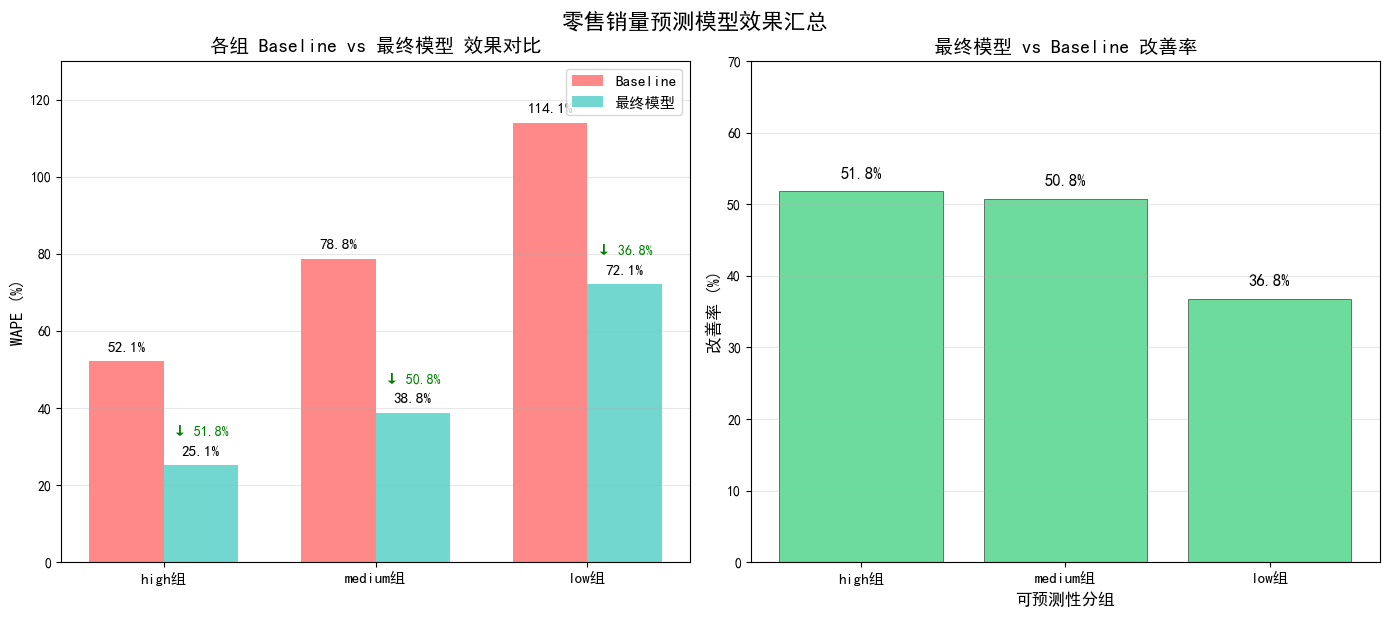


最终模型效果汇总
     分组    最终模型 Baseline WAPE 最终模型 WAPE   改善率
  high组  简单平均融合         52.1%     25.1% 51.8%
medium组   中位数融合         78.8%     38.8% 50.8%
   low组 XGBoost        114.1%     72.1% 36.8%


In [18]:
# ==========================================
# Cell 8: 最终模型效果可视化
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 最终结果数据
groups = ['high', 'medium', 'low']
baseline_wape = [52.11, 78.76, 114.07]
final_wape = [25.12, 38.75, 72.07]  # high: 简单平均, medium: 中位数融合, low: XGBoost
improvement = [51.79, 50.80, 36.82]

# 创建画布
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ========== 图1：Baseline vs 最终模型 WAPE 对比 ==========
ax1 = axes[0]
x = np.arange(len(groups))
width = 0.35

bars1 = ax1.bar(x - width/2, baseline_wape, width, label='Baseline', color='#ff6b6b', alpha=0.8)
bars2 = ax1.bar(x + width/2, final_wape, width, label='最终模型', color='#4ecdc4', alpha=0.8)

# 添加数值标签
for bar, val in zip(bars1, baseline_wape):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, final_wape):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 在最终模型柱子上方标注改善率（放在柱子内部顶部或外部上方）
for i, (baseline, final) in enumerate(zip(baseline_wape, final_wape)):
    impr = (baseline - final) / baseline * 100
    color = 'green' if impr > 0 else 'red'
    # 改善率标签放在最终模型柱子的顶部（柱子外部）
    ax1.annotate(f'↓ {impr:.1f}%', xy=(i + width/2, final + 7), 
                 ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')

ax1.set_ylabel('WAPE (%)', fontsize=12)
ax1.set_title('各组 Baseline vs 最终模型 效果对比', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{g}组' for g in groups], fontsize=11)
ax1.legend(loc='upper right', fontsize=11)
ax1.set_ylim(0, 130)
ax1.grid(True, alpha=0.3, axis='y')

# ========== 图2：改善率柱状图 ==========
ax2 = axes[1]
colors = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvement]
bars = ax2.bar(groups, improvement, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# 改善率数值标签（放在柱子顶部上方）
for bar, imp in zip(bars, improvement):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, 
             f'{imp:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylabel('改善率 (%)', fontsize=12)
ax2.set_xlabel('可预测性分组', fontsize=12)
ax2.set_title('最终模型 vs Baseline 改善率', fontsize=14, fontweight='bold')
ax2.set_xticklabels([f'{g}组' for g in groups], fontsize=11)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylim(0, 70)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('零售销量预测模型效果汇总', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# ========== 额外：输出最终结果表格 ==========
print("\n" + "="*60)
print("最终模型效果汇总")
print("="*60)
result_df = pd.DataFrame({
    '分组': ['high组', 'medium组', 'low组'],
    '最终模型': ['简单平均融合', '中位数融合', 'XGBoost'],
    'Baseline WAPE': [f'{b:.1f}%' for b in baseline_wape],
    '最终模型 WAPE': [f'{f:.1f}%' for f in final_wape],
    '改善率': [f'{i:.1f}%' for i in improvement]
})
print(result_df.to_string(index=False))

In [45]:
# ==========================================
# Cell 9a: 短时序 Optuna 超参数调优 (保存缓存)
# ==========================================
import pandas as pd
import numpy as np
import warnings
import pickle
warnings.filterwarnings('ignore')

import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb

print("="*60)
print("短时序 Optuna 超参数调优")
print("="*60)

# -------------------- 辅助函数 --------------------
def wape_fn(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

# -------------------- 1. 读取数据 --------------------
df = pd.read_parquet('monthly_aggregated_sales_16features_with_holidays_predict.parquet')
short_term_df = df[df['predictability_level'].isna()].copy()
print(f"短时序数据量: {len(short_term_df):,} 行")
print(f"组合数: {short_term_df.groupby(['ref_branch_code', 'material_nature_sum_desc']).ngroups}")

# -------------------- 2. 特征工程 --------------------
def create_time_features(df):
    df = df.copy()
    df['month'] = pd.to_datetime(df['month'])
    df['year'] = df['month'].dt.year
    df['month_num'] = df['month'].dt.month
    df['quarter'] = df['month'].dt.quarter
    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
    return df

def encode_categoricals(train, test, cat_features):
    train = train.copy()
    test = test.copy()
    for col in cat_features:
        le = LabelEncoder()
        combined = pd.concat([train[col], test[col]], axis=0).astype(str).unique()
        le.fit(combined)
        train[col] = le.transform(train[col].astype(str))
        test[col] = le.transform(test[col].astype(str))
    return train, test

cat_features = [
    'Business_Type_1_Desc', 'Type_Group_Desc', 'Shop_Style_Desc',
    'City_Description', 'City', 'Province_Description',
    'City_Level_Description', 'District_Desc', 'Geographic_Region_Desc',
    'Mall_Scale_Code_Desc', 'shop_type_desc'
]

holiday_cols = [col for col in short_term_df.columns if col.startswith('holiday_') and col.endswith('_flag')]
holiday_cols.append('total_holiday_days')

base_features = [
    'year', 'month_num', 'quarter', 'month_sin', 'month_cos',
    'price'
] + holiday_cols + cat_features

print(f"特征数量: {len(base_features)}")

# -------------------- 3. 按组合拆分训练/测试 --------------------
train_list, test_list = [], []
train_raw_list, test_raw_list = [], []

group_cols = ['ref_branch_code', 'material_nature_sum_desc']
target = 'monthly_sales'

for (store, prod), group in short_term_df.groupby(group_cols):
    group = group.sort_values('month')
    n = len(group)
    if n < 6:
        continue
    split_idx = int(n * 0.8)
    train_group = group.iloc[:split_idx].copy()
    test_group = group.iloc[split_idx:].copy()
    train_list.append(train_group)
    test_list.append(test_group)
    # 保存原始数据 (含 group 列供 DL 模型安全序列构造)
    train_raw_list.append(train_group[['ref_branch_code', 'material_nature_sum_desc', 'month', 'monthly_sales']].copy())
    test_raw_list.append(test_group[['ref_branch_code', 'material_nature_sum_desc', 'month', 'monthly_sales']].copy())

train_raw_all = pd.concat(train_raw_list, ignore_index=True)
test_raw_all = pd.concat(test_raw_list, ignore_index=True)
train_all = pd.concat(train_list, ignore_index=True)
test_all = pd.concat(test_list, ignore_index=True)

print(f"训练集: {len(train_all):,} 行, 测试集: {len(test_all):,} 行, 组合数: {len(train_list)}")

# -------------------- 4. 特征工程执行 --------------------
train_all = create_time_features(train_all)
test_all = create_time_features(test_all)
train_all, test_all = encode_categoricals(train_all, test_all, cat_features)

X_train = train_all[base_features].fillna(0)
y_train = train_all[target]
X_test = test_all[base_features].fillna(0)
y_test = test_all[target]

# 训练集内再切验证集 (15%)
n_train = len(X_train)
val_size = int(n_train * 0.15)
train_size = n_train - val_size

X_train_strict = X_train.iloc[:train_size]
y_train_strict = y_train.iloc[:train_size]
X_val = X_train.iloc[train_size:]
y_val = y_train.iloc[train_size:]

print(f"训练/验证/测试: {train_size:,} / {val_size:,} / {len(X_test):,}")

# -------------------- 5. 简单基准模型 --------------------
print("\n" + "="*60)
print("训练简单基准模型")
print("="*60)

mean_wapes = []
seasonal_wapes = []

for (store, prod), group in short_term_df.groupby(group_cols):
    group = group.sort_values('month')
    n = len(group)
    if n < 6:
        continue
    split_idx = int(n * 0.8)
    train_series = group.iloc[:split_idx]['monthly_sales'].values
    test_series = group.iloc[split_idx:]['monthly_sales'].values
    if len(test_series) == 0:
        continue
    # 均值法
    mean_wapes.append(wape_fn(test_series, np.full(len(test_series), train_series.mean())))
    # 季节性朴素法
    if len(train_series) >= 12:
        pattern = train_series[-12:]
        repeats = len(test_series) // 12 + 1
        seasonal_pred = np.tile(pattern, repeats)[:len(test_series)]
    else:
        seasonal_pred = np.full(len(test_series), train_series.mean())
    seasonal_wapes.append(wape_fn(test_series, seasonal_pred))

mean_wape_avg = np.mean(mean_wapes)
seasonal_wape_avg = np.mean(seasonal_wapes)
best_baseline = min(mean_wape_avg, seasonal_wape_avg)
print(f"均值法 WAPE: {mean_wape_avg:.2f}%")
print(f"季节性朴素法 WAPE: {seasonal_wape_avg:.2f}%")
print(f"最佳 Baseline WAPE: {best_baseline:.2f}%")

# -------------------- 6. Optuna 超参数优化函数 --------------------
print("\n" + "="*60)
print("Optuna 调参函数定义")
print("="*60)

def optimize_lgb_short(X_tr, y_tr, X_v, y_v, n_trials=50):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        }
        model = lgb.LGBMRegressor(objective='regression', metric='mape', random_state=42, n_jobs=-1, verbose=-1, **params)
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], eval_metric='mape',
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        return wape_fn(y_v, model.predict(X_v))
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_model = lgb.LGBMRegressor(objective='regression', random_state=42, n_jobs=-1, **study.best_params)
    best_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], eval_metric='mape', callbacks=[lgb.early_stopping(50, verbose=False)])
    return best_model, study.best_params, study.best_value

def optimize_xgb_short(X_tr, y_tr, X_v, y_v, n_trials=50):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 0.5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='mape', random_state=42, n_jobs=-1, verbosity=0, **params)
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        return wape_fn(y_v, model.predict(X_v))
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0, **study.best_params)
    best_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    return best_model, study.best_params, study.best_value

def optimize_rf_short(X_tr, y_tr, X_v, y_v, n_trials=30):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        }
        model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        model.fit(X_tr, y_tr)
        return wape_fn(y_v, model.predict(X_v))
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_model = RandomForestRegressor(random_state=42, n_jobs=-1, **study.best_params)
    best_model.fit(X_tr, y_tr)
    return best_model, study.best_params, study.best_value

def optimize_gbdt_short(X_tr, y_tr, X_v, y_v, n_trials=30):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        }
        model = GradientBoostingRegressor(random_state=42, **params)
        model.fit(X_tr, y_tr)
        return wape_fn(y_v, model.predict(X_v))
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_model = GradientBoostingRegressor(random_state=42, **study.best_params)
    best_model.fit(X_tr, y_tr)
    return best_model, study.best_params, study.best_value

# -------------------- 7. 执行 Optuna 调参 --------------------
print("\n" + "="*60)
print("开始 Optuna 超参数优化 (短时序)")
print("="*60)

tuned_models_short = {}
val_wape_summary = {}

for name, func, n_trials in [
    ('RandomForest', optimize_rf_short, 30),
    ('GBDT', optimize_gbdt_short, 30),
    ('LightGBM', optimize_lgb_short, 50),
    ('XGBoost', optimize_xgb_short, 50),
]:
    print(f"\n  [{name}] 开始调参 (n_trials={n_trials})...")
    best_model, best_params, best_wape = func(X_train_strict, y_train_strict, X_val, y_val, n_trials=n_trials)
    tuned_models_short[name] = {'model': best_model, 'params': best_params, 'best_val_wape': best_wape}
    val_wape_summary[f'{name}_Val_WAPE'] = best_wape
    print(f"  [{name}] 最佳验证WAPE: {best_wape:.4f}")

print("\n" + "="*60)
print("短时序 Optuna 调参完成！")
print("="*60)

# -------------------- 8. 保存缓存 --------------------
# 验证集 WAPE 汇总
val_summary_df = pd.DataFrame([val_wape_summary])
print("\n========== 短时序调优：验证集最佳 WAPE 汇总 ==========")
print(val_summary_df.round(2).to_string(index=False))
val_summary_df.to_csv('tuning_validation_best_wape_short.csv', index=False)
print("\n验证集最佳WAPE汇总表已保存至 tuning_validation_best_wape_short.csv")

# 保存调参后的模型
with open('tuned_models_short.pkl', 'wb') as f:
    pickle.dump(tuned_models_short, f)
print("调参后的短时序模型已保存至 tuned_models_short.pkl")

# 保存 Baseline
pd.DataFrame([{'model': '均值法', 'wape': mean_wape_avg},
              {'model': '季节性朴素法', 'wape': seasonal_wape_avg},
              {'model': 'best_baseline', 'wape': best_baseline}]).to_csv(
    'short_term_baseline.csv', index=False)
print("Baseline 已保存至 short_term_baseline.csv")

print("\n✅ Cell 29 完成：调参结果已缓存，可运行 Cell 30 进行模型训练与评估")


短时序数据建模与评估
短时序数据量: 21,060 行
组合数: 1706

使用的基础特征: ['year', 'month_num', 'quarter', 'month_sin', 'month_cos', 'price', 'holiday_NewYear_flag', 'holiday_WomenDay_flag', 'holiday_LabourDay_flag', 'holiday_ChildrenDay_flag', 'holiday_NationalDay_flag', 'holiday_DragonBoat_flag', 'holiday_MidAutumn_flag', 'holiday_SpringFestival_flag', 'total_holiday_days', 'Business_Type_1_Desc', 'Type_Group_Desc', 'Shop_Style_Desc', 'City_Description', 'City', 'Province_Description', 'City_Level_Description', 'District_Desc', 'Geographic_Region_Desc', 'Mall_Scale_Code_Desc', 'shop_type_desc']
特征数量: 26

按时间顺序划分训练集和测试集
训练集行数: 15,778
测试集行数: 4,622
有效组合数: 1319

树模型数据划分:
  训练集 (65%总量): 13,412 行
  验证集 (15%总量): 2,366 行
  测试集 (20%总量): 4,622 行

训练简单基准模型
均值法 WAPE: 77.05%
季节性朴素法 WAPE: 81.33%
最佳 Baseline WAPE: 77.05%

训练 Ridge 线性回归
Ridge WAPE: 153.85%

训练 LightGBM
LightGBM WAPE: 92.76%
最佳迭代轮数: 395

训练 XGBoost


21:39:25 - cmdstanpy - INFO - Chain [1] start processing


XGBoost WAPE: 95.72%

运行 Prophet（抽样）


21:39:31 - cmdstanpy - INFO - Chain [1] done processing
21:39:31 - cmdstanpy - INFO - Chain [1] start processing
21:39:31 - cmdstanpy - INFO - Chain [1] done processing
21:39:31 - cmdstanpy - INFO - Chain [1] start processing
21:39:37 - cmdstanpy - INFO - Chain [1] done processing
21:39:37 - cmdstanpy - INFO - Chain [1] start processing
21:39:37 - cmdstanpy - INFO - Chain [1] done processing
21:39:37 - cmdstanpy - INFO - Chain [1] start processing
21:39:37 - cmdstanpy - INFO - Chain [1] done processing
21:39:37 - cmdstanpy - INFO - Chain [1] start processing
21:39:39 - cmdstanpy - INFO - Chain [1] done processing
21:39:39 - cmdstanpy - INFO - Chain [1] start processing
21:39:39 - cmdstanpy - INFO - Chain [1] done processing
21:39:39 - cmdstanpy - INFO - Chain [1] start processing
21:39:39 - cmdstanpy - INFO - Chain [1] done processing
21:39:39 - cmdstanpy - INFO - Chain [1] start processing
21:39:39 - cmdstanpy - INFO - Chain [1] done processing
21:39:39 - cmdstanpy - INFO - Chain [1] 

Prophet (抽样50个) WAPE: 760.87%

短时序模型结果汇总
   model   wape
     均值法  77.05
  季节性朴素法  81.33
LightGBM  92.76
 XGBoost  95.72
   Ridge 153.85
 Prophet 760.87

最佳模型: 均值法
最佳 WAPE: 77.05%
Baseline (最佳简单基准): 77.05%
改善率: +0.00%

结果已保存至 short_term_model_results.csv

短时序处理建议
✅ 短时序数据量少，建议使用简单基准模型: 均值法
   WAPE = 77.05%


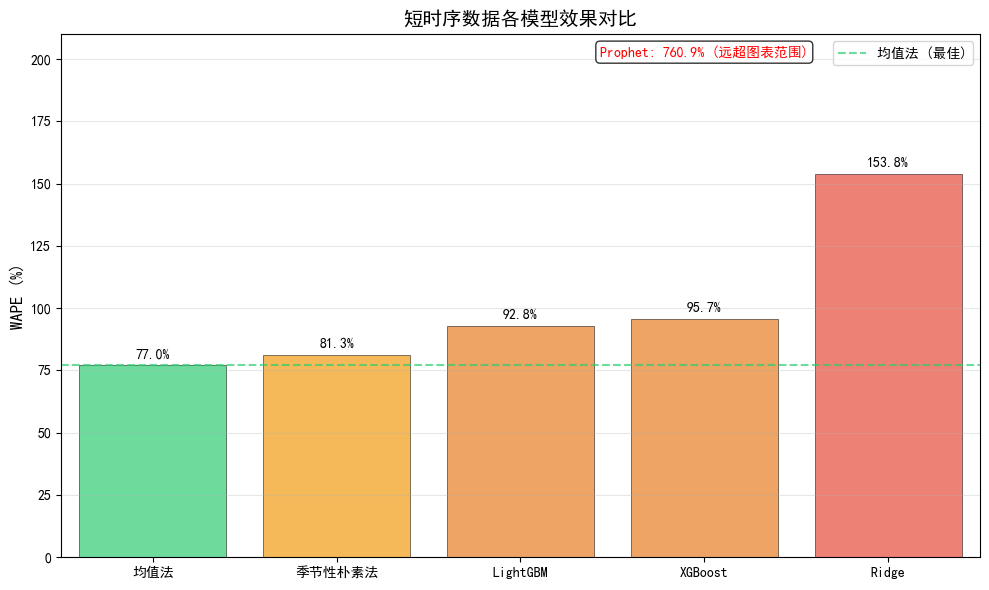

In [46]:
# ==========================================
# Cell 9b: 短时序模型训练与评估 (优先读取缓存)
# ==========================================
import pandas as pd
import numpy as np
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet

# PyTorch
import torch
import torch.nn as nn
import importlib, sys
sys.path.insert(0, '.')
try:
    import dl_models_improved
    from dl_models_improved import run_dl_experiment
    importlib.reload(dl_models_improved)
    HAS_DL_MODULE = True
except ImportError:
    HAS_DL_MODULE = False
    run_dl_experiment = None

print("="*60)
print("短时序模型训练与评估 (缓存优先)")
print("="*60)

# -------------------- 辅助函数 --------------------
def wape_fn(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

# -------------------- 1. 优先读取调参缓存 --------------------
print("\n" + "="*60)
print("Step 1: 加载调参缓存")
print("="*60)

try:
    with open('tuned_models_short.pkl', 'rb') as f:
        tuned_models_short = pickle.load(f)
    print("✅ 从缓存加载 tuned_models_short.pkl")
    print(f"包含模型: {list(tuned_models_short.keys())}")
    for name, info in tuned_models_short.items():
        print(f"  {name:15s} -> val_wape = {info['best_val_wape']:.2f}%")
    skip_tuning = True
except FileNotFoundError:
    print("❌ 未找到 tuned_models_short.pkl")
    print("请先运行 Cell 29 进行 Optuna 调参，或设置 skip_tuning=False 并取消下方注释以快速调参")
    skip_tuning = True  # 改为 False 则尝试快速调参
    # raise SystemExit("需要先运行 Cell 29")

# -------------------- 2. 加载数据与特征工程 (依赖 Cell 29 的变量) --------------------
print("\n" + "="*60)
print("Step 2: 准备数据")
print("="*60)

# 检查变量是否已存在 (从 Cell 29 继承)
vars_needed = ['X_train', 'y_train', 'X_test', 'y_test', 'X_val', 'y_val',
               'train_raw_all', 'test_raw_all', 'short_term_df',
               'mean_wape_avg', 'seasonal_wape_avg', 'best_baseline',
               'group_cols', 'target', 'base_features', 'cat_features']

missing_vars = [v for v in vars_needed if v not in dir()]
if missing_vars:
    print(f"⚠️ 以下变量缺失，重新运行数据准备: {missing_vars}")
    # 回退：重新加载数据
    df = pd.read_parquet('monthly_aggregated_sales_16features_with_holidays_predict.parquet')
    short_term_df = df[df['predictability_level'].isna()].copy()
    
    group_cols = ['ref_branch_code', 'material_nature_sum_desc']
    target = 'monthly_sales'
    
    cat_features = [
        'Business_Type_1_Desc', 'Type_Group_Desc', 'Shop_Style_Desc',
        'City_Description', 'City', 'Province_Description',
        'City_Level_Description', 'District_Desc', 'Geographic_Region_Desc',
        'Mall_Scale_Code_Desc', 'shop_type_desc'
    ]
    
    holiday_cols = [col for col in short_term_df.columns if col.startswith('holiday_') and col.endswith('_flag')]
    holiday_cols.append('total_holiday_days')
    base_features = ['year', 'month_num', 'quarter', 'month_sin', 'month_cos', 'price'] + holiday_cols + cat_features
    
    # 简化版数据准备 (不重复 Cell 29 全部代码，直接构造最小可运行版本)
    def create_time_features(df):
        df = df.copy()
        df['month'] = pd.to_datetime(df['month'])
        df['year'] = df['month'].dt.year
        df['month_num'] = df['month'].dt.month
        df['quarter'] = df['month'].dt.quarter
        df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
        return df
    
    def encode_categoricals(train, test, cat_features):
        train, test = train.copy(), test.copy()
        for col in cat_features:
            le = LabelEncoder()
            combined = pd.concat([train[col], test[col]], axis=0).astype(str).unique()
            le.fit(combined)
            train[col] = le.transform(train[col].astype(str))
            test[col] = le.transform(test[col].astype(str))
        return train, test
    
    train_list, test_list = [], []
    train_raw_list, test_raw_list = [], []
    for (store, prod), group in short_term_df.groupby(group_cols):
        group = group.sort_values('month')
        n = len(group)
        if n < 6:
            continue
        split_idx = int(n * 0.8)
        train_group, test_group = group.iloc[:split_idx].copy(), group.iloc[split_idx:].copy()
        train_list.append(train_group)
        test_list.append(test_group)
        train_raw_list.append(train_group[['ref_branch_code', 'material_nature_sum_desc', 'month', 'monthly_sales']].copy())
        test_raw_list.append(test_group[['ref_branch_code', 'material_nature_sum_desc', 'month', 'monthly_sales']].copy())
    
    train_raw_all = pd.concat(train_raw_list, ignore_index=True)
    test_raw_all = pd.concat(test_raw_list, ignore_index=True)
    train_all = pd.concat(train_list, ignore_index=True)
    test_all = pd.concat(test_list, ignore_index=True)
    
    train_all = create_time_features(train_all)
    test_all = create_time_features(test_all)
    train_all, test_all = encode_categoricals(train_all, test_all, cat_features)
    
    X_train = train_all[base_features].fillna(0)
    y_train = train_all[target]
    X_test = test_all[base_features].fillna(0)
    y_test = test_all[target]
    
    n_train = len(X_train)
    val_size = int(n_train * 0.15)
    X_val = X_train.iloc[n_train - val_size:]
    y_val = y_train.iloc[n_train - val_size:]
    
    # 简化 Baseline (直接读缓存)
    try:
        baseline_df = pd.read_csv('short_term_baseline.csv')
        mean_wape_avg = baseline_df[baseline_df['model'] == '均值法']['wape'].values[0]
        seasonal_wape_avg = baseline_df[baseline_df['model'] == '季节性朴素法']['wape'].values[0]
        best_baseline = baseline_df[baseline_df['model'] == 'best_baseline']['wape'].values[0]
    except FileNotFoundError:
        mean_wape_avg = seasonal_wape_avg = best_baseline = np.nan
    print("✅ 数据准备完成 (回退模式)")
else:
    print("✅ 使用 Cell 29 的数据变量")

# -------------------- 3. 树模型测试集评估 (使用缓存的最佳参数+完整训练集) --------------------
print("\n" + "="*60)
print("Step 3: 树模型测试集评估")
print("="*60)

all_test_preds = {}
test_results = []

for model_name, model_info in tuned_models_short.items():
    # 从缓存中获取最佳参数，用完整训练集重新训练
    best_params = model_info['params']
    print(f"\n  [{model_name}] 最佳参数: {best_params}")
    
    if model_name == 'RandomForest':
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
        model.fit(X_train, y_train)
    elif model_name == 'GBDT':
        from sklearn.ensemble import GradientBoostingRegressor
        model = GradientBoostingRegressor(random_state=42, **best_params)
        model.fit(X_train, y_train)
    elif model_name == 'LightGBM':
        model = lgb.LGBMRegressor(objective='regression', random_state=42, n_jobs=-1, verbose=-1, **best_params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='mape',
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    elif model_name == 'XGBoost':
        model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0, **best_params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    y_pred = model.predict(X_test)
    y_pred = np.maximum(0, y_pred)
    all_test_preds[model_name] = y_pred
    wape_val = wape_fn(y_test.values, y_pred)
    
    test_results.append({'model': model_name, 'wape': wape_val,
                         'best_params': best_params,
                         'best_val_wape': model_info['best_val_wape']})
    print(f"  [{model_name}] 测试集 WAPE = {wape_val:.2f}% (验证集 = {model_info['best_val_wape']:.2f}%)")

# -------------------- 4. Ridge 线性回归 --------------------
print("\n" + "="*60)
print("Step 4: Ridge 线性回归")
print("="*60)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = np.maximum(0, ridge_model.predict(X_test))
all_test_preds['Ridge'] = y_pred_ridge
ridge_wape = wape_fn(y_test.values, y_pred_ridge)
print(f"Ridge WAPE: {ridge_wape:.2f}%")

# -------------------- 5. Prophet（抽样）--------------------
print("\n" + "="*60)
print("Step 5: Prophet (抽样)")
print("="*60)

all_groups = short_term_df[group_cols].drop_duplicates()
sample_groups = all_groups.sample(n=min(50, len(all_groups)), random_state=42)

prophet_y_true, prophet_y_pred = [], []
for _, (store, prod) in sample_groups.iterrows():
    group_data = short_term_df[(short_term_df['ref_branch_code'] == store) & 
                                (short_term_df['material_nature_sum_desc'] == prod)].sort_values('month')
    if len(group_data) < 6:
        continue
    n = len(group_data)
    train_group = group_data.iloc[:int(n * 0.8)]
    test_group = group_data.iloc[int(n * 0.8):]
    if len(test_group) == 0 or len(train_group) < 6:
        continue
    try:
        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        model.fit(train_group[['month', 'monthly_sales']].rename(columns={'month': 'ds', 'monthly_sales': 'y'}))
        forecast = model.predict(test_group[['month']].rename(columns={'month': 'ds'}))
        prophet_y_true.extend(test_group['monthly_sales'].values)
        prophet_y_pred.extend(forecast['yhat'].values)
    except Exception:
        continue

prophet_wape = wape_fn(np.array(prophet_y_true), np.array(prophet_y_pred)) if prophet_y_true else np.nan
print(f"Prophet (抽样{len(sample_groups)}个) WAPE: {prophet_wape:.2f}%" if not np.isnan(prophet_wape) else "Prophet 运行失败")

# -------------------- 6. LSTM + Transformer --------------------
print("\n" + "="*60)
print("Step 6: 深度学习模型 (LSTM + Transformer)")
print("="*60)

dl_results = {}

if HAS_DL_MODULE:
    # 自适应 seq_length
    group_lengths = train_raw_all.groupby(group_cols).size()
    usable_seq = min(12, max(3, int(group_lengths.quantile(0.25))))
    print(f"使用 dl_models_improved 模块, seq_length={usable_seq}")
    
    for dl_name, dl_type in [('LSTM', 'lstm'), ('Transformer', 'transformer')]:
        try:
            y_pred_dl, mape_dl, wape_dl, dl_model = run_dl_experiment(
                train_raw_all.copy(), test_raw_all.copy(),
                model_type=dl_type, seq_length=usable_seq,
                epochs=100, batch_size=32, patience=15, lr=0.001, weight_decay=1e-5
            )
            dl_results[dl_name] = {'y_pred': y_pred_dl, 'wape': wape_dl, 'model': dl_model}
            print(f"  {dl_name}: WAPE = {wape_dl:.2f}%")
        except Exception as e:
            print(f"  {dl_name} 失败: {e}")
else:
    # 内置简化模型
    print("使用内置简化 PyTorch 模型")
    
    class RetailLSTM_Short(nn.Module):
        def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])
    
    class PositionalEncoding(nn.Module):
        def __init__(self, d_model, max_len=50):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len).unsqueeze(1).float()
            div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            self.register_buffer('pe', pe.unsqueeze(0))
        def forward(self, x):
            return x + self.pe[:, :x.size(1), :]
    
    class RetailTransformer_Short(nn.Module):
        def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
            super().__init__()
            self.input_proj = nn.Linear(input_size, d_model)
            self.pos_encoder = PositionalEncoding(d_model)
            encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(d_model, 1)
        def forward(self, x):
            x = self.input_proj(x)
            x = self.pos_encoder(x)
            x = self.transformer(x)
            return self.fc(x[:, -1, :])
    
    seq_length = 6
    scaler_X, scaler_y = StandardScaler(), StandardScaler()
    X_scaled = scaler_X.fit_transform(X_train.values)
    y_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    X_test_scaled = scaler_X.transform(X_test.values)
    
    def create_sequences(X, y, seq_len):
        return (np.array([X[i:i+seq_len] for i in range(len(X)-seq_len)]),
                np.array([y[i+seq_len] for i in range(len(X)-seq_len)]))
    
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length)
    
    if len(X_seq) > 0 and len(X_test_seq) > 0:
        X_seq_t = torch.FloatTensor(X_seq)
        y_seq_t = torch.FloatTensor(y_seq).unsqueeze(1)
        X_test_t = torch.FloatTensor(X_test_seq)
        
        for dl_name, ModelClass in [('LSTM', RetailLSTM_Short), ('Transformer', RetailTransformer_Short)]:
            try:
                model = ModelClass(input_size=X_seq.shape[2])
                opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
                sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
                criterion = nn.MSELoss()
                best_loss, patience_cnt, best_state = float('inf'), 0, None
                
                for epoch in range(100):
                    model.train()
                    opt.zero_grad()
                    loss = criterion(model(X_seq_t), y_seq_t)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    sched.step(loss)
                    if loss.item() < best_loss:
                        best_loss = loss.item()
                        patience_cnt = 0
                        best_state = {k: v.clone() for k, v in model.state_dict().items()}
                    else:
                        patience_cnt += 1
                    if patience_cnt >= 15:
                        break
                
                model.load_state_dict(best_state)
                model.eval()
                with torch.no_grad():
                    y_pred_dl = scaler_y.inverse_transform(model(X_test_t).numpy()).ravel()
                y_pred_dl = np.maximum(0, y_pred_dl)
                # 长度对齐
                if len(y_pred_dl) > len(y_test):
                    y_pred_dl = y_pred_dl[-len(y_test):]
                elif len(y_pred_dl) < len(y_test):
                    y_pred_dl = np.concatenate([np.full(len(y_test)-len(y_pred_dl), y_train.mean()), y_pred_dl])
                y_pred_dl = np.maximum(0, y_pred_dl)
                wape_dl = wape_fn(y_test.values[:len(y_pred_dl)], y_pred_dl[:len(y_test.values)])
                dl_results[dl_name] = {'y_pred': y_pred_dl, 'wape': wape_dl, 'model': model}
                print(f"  {dl_name}: WAPE = {wape_dl:.2f}%")
            except Exception as e:
                print(f"  {dl_name} 失败: {e}")
    else:
        print("  序列数据不足，跳过 DL")

# -------------------- 7. 模型融合 --------------------
print("\n" + "="*60)
print("Step 7: 模型融合 (4种方法)")
print("="*60)

# 收集所有模型测试集 WAPE
all_models_wape = {tr['model']: tr['wape'] for tr in test_results}
all_models_wape['Ridge'] = ridge_wape
for dl_name, dl_info in dl_results.items():
    all_models_wape[dl_name] = dl_info['wape']

sorted_models = sorted(all_models_wape.items(), key=lambda x: x[1])
top3_names = [name for name, _ in sorted_models[:3]]
top3_wapes = [all_models_wape[name] for name in top3_names]

print(f"\n所有模型排名:")
for i, (name, w) in enumerate(sorted_models):
    print(f"  {i+1}. {name:15s} WAPE = {w:.2f}%")
print(f"\nTop 3 融合模型: {top3_names}")

# 收集预测并对齐
ensemble_preds = {}
for name in top3_names:
    if name in all_test_preds:
        ensemble_preds[name] = all_test_preds[name]
    elif name in dl_results:
        ensemble_preds[name] = dl_results[name]['y_pred']
    elif name == 'Ridge':
        ensemble_preds[name] = all_test_preds['Ridge']

if len(ensemble_preds) >= 2:
    min_len = min(len(pred) for pred in ensemble_preds.values())
    y_test_aligned = y_test.values[-min_len:]
    for name in ensemble_preds:
        ensemble_preds[name] = ensemble_preds[name][-min_len:]
    
    # 权重
    weights = [1/w for w in top3_wapes]
    weights = [w/sum(weights) for w in weights]
    
    # 4种融合
    ensemble_avg = np.mean(list(ensemble_preds.values()), axis=0)
    wape_avg = wape_fn(y_test_aligned, ensemble_avg)
    
    ensemble_weighted = np.zeros(min_len)
    for name, w in zip(top3_names, weights):
        if name in ensemble_preds:
            ensemble_weighted += w * ensemble_preds[name]
    wape_weighted = wape_fn(y_test_aligned, ensemble_weighted)
    
    ensemble_median = np.median(list(ensemble_preds.values()), axis=0)
    wape_median = wape_fn(y_test_aligned, ensemble_median)
    
    if len(ensemble_preds) >= 3:
        all_preds_matrix = np.array(list(ensemble_preds.values()))
        ensemble_trimmed = np.mean(np.sort(all_preds_matrix, axis=0)[1:-1], axis=0)
        wape_trimmed = wape_fn(y_test_aligned, ensemble_trimmed)
    else:
        wape_trimmed, ensemble_trimmed = wape_avg, ensemble_avg
    
    print(f"\n融合结果 (测试集):")
    print(f"  简单平均: {wape_avg:.2f}%")
    print(f"  加权平均: {wape_weighted:.2f}%")
    print(f"  中位数:   {wape_median:.2f}%")
    print(f"  截尾平均: {wape_trimmed:.2f}%")
    
    best_single_wape = top3_wapes[0]
    print(f"\nvs 最佳单模型 ({top3_names[0]} = {best_single_wape:.2f}%):")
    print(f"  简单平均改善: {(best_single_wape-wape_avg)/best_single_wape*100:+.2f}%")
    print(f"  加权平均改善: {(best_single_wape-wape_weighted)/best_single_wape*100:+.2f}%")
    print(f"  中位数改善:   {(best_single_wape-wape_median)/best_single_wape*100:+.2f}%")
    print(f"  截尾平均改善: {(best_single_wape-wape_trimmed)/best_single_wape*100:+.2f}%")
else:
    wape_avg = wape_weighted = wape_median = wape_trimmed = np.nan
    print("  模型不足，跳过融合")

# -------------------- 8. 结果汇总与保存 (含 Baseline 对比) --------------------
print("\n" + "="*60)
print("Step 8: 结果汇总 (含 Baseline 对比)")
print("="*60)

# 收集所有模型结果
results = []
# Baseline 模型
results.append({'model': 'Baseline_均值法', 'wape': mean_wape_avg})
results.append({'model': 'Baseline_季节性朴素法', 'wape': seasonal_wape_avg})
results.append({'model': 'Ridge', 'wape': ridge_wape})
for tr in test_results:
    results.append({'model': tr['model'], 'wape': tr['wape']})
for dl_name, dl_info in dl_results.items():
    results.append({'model': dl_name, 'wape': dl_info['wape']})
if not np.isnan(prophet_wape):
    results.append({'model': 'Prophet', 'wape': prophet_wape})
if not np.isnan(wape_avg):
    results.append({'model': 'Ensemble_Avg', 'wape': wape_avg})
    results.append({'model': 'Ensemble_Weighted', 'wape': wape_weighted})
    results.append({'model': 'Ensemble_Median', 'wape': wape_median})
    results.append({'model': 'Ensemble_Trimmed', 'wape': wape_trimmed})

results_df = pd.DataFrame(results)

# 计算相对 Baseline 的改善率
# 使用 best_baseline (均值法与季节性朴素法中较优者) 作为基准
if not np.isnan(best_baseline):
    results_df['improvement_vs_baseline'] = (best_baseline - results_df['wape']) / best_baseline * 100
else:
    results_df['improvement_vs_baseline'] = np.nan

results_df = results_df.sort_values('wape')

# 格式化输出
print(f"\n{'='*80}")
print(f"短时序模型效果对比 (Baseline = {best_baseline:.2f}% WAPE)")
print(f"{'='*80}")
print(f"{'模型':25s} {'WAPE':>8s} {'vs Baseline':>12s} {'评级':>6s}")
print(f"{'-'*55}")

for _, row in results_df.iterrows():
    model = row['model']
    wape = row['wape']
    imp = row['improvement_vs_baseline']

    if model.startswith('Baseline_'):
        tag = '(基准)'
        rating = '--'
    elif imp > 0:
        tag = ''
        rating = 'BEST' if model == results_df.iloc[0]['model'] else 'GOOD'
    else:
        tag = ''
        rating = 'POOR'

    print(f"{model:25s} {wape:8.2f}% {imp:+11.2f}% {rating:>6s} {tag}")

print(f"{'='*80}")

best_model_name = results_df.iloc[0]['model']
best_model_wape = results_df.iloc[0]['wape']
improvement_vs_baseline = results_df.iloc[0]['improvement_vs_baseline']

# 统计
n_better = (results_df['improvement_vs_baseline'] > 0).sum()
n_total = (~results_df['model'].str.startswith('Baseline_')).sum()
print(f"\n📊 统计: {n_better}/{n_total} 个模型优于 Baseline")
print(f"🏆 最佳模型: {best_model_name} (WAPE = {best_model_wape:.2f}%, 改善 = {improvement_vs_baseline:+.2f}%)")

# 按类别汇总
print(f"\n--- 按模型类别汇总 ---")
categories = {
    'Baseline': ['Baseline_均值法', 'Baseline_季节性朴素法'],
    'Tree': ['RandomForest', 'GBDT', 'LightGBM', 'XGBoost'],
    'Linear': ['Ridge'],
    'DL': ['LSTM', 'Transformer'],
    'Prophet': ['Prophet'],
    'Ensemble': ['Ensemble_Avg', 'Ensemble_Weighted', 'Ensemble_Median', 'Ensemble_Trimmed'],
}
for cat, names in categories.items():
    cat_rows = results_df[results_df['model'].isin(names)]
    if len(cat_rows) > 0:
        best = cat_rows.iloc[0]
        print(f"  {cat:10s}: 最佳 {best['model']:20s} WAPE={best['wape']:.2f}%  改善={best['improvement_vs_baseline']:+.2f}%")

# 保存 (包含改善率)
results_df.to_csv('short_term_model_results.csv', index=False)
print("\n✅ 最终结果 (含 Baseline 对比) 已保存至 short_term_model_results.csv")

# 调参详情
pd.DataFrame(test_results).to_csv('short_term_tuning_details.csv', index=False)
print("✅ 调参详情已保存至 short_term_tuning_details.csv")

# 融合详情
if not np.isnan(wape_avg):
    pd.DataFrame([
        {'model': 'Ensemble_Avg', 'wape': wape_avg, 'method': '简单平均融合'},
        {'model': 'Ensemble_Weighted', 'wape': wape_weighted, 'method': '加权平均融合'},
        {'model': 'Ensemble_Median', 'wape': wape_median, 'method': '中位数融合'},
        {'model': 'Ensemble_Trimmed', 'wape': wape_trimmed, 'method': '截尾平均融合'},
    ]).to_csv('short_term_ensemble_results.csv', index=False)
    print("✅ 融合结果已保存至 short_term_ensemble_results.csv")

# -------------------- 9. 最终建议 --------------------
print("\n" + "="*60)
print("短时序处理建议")
print("="*60)

if best_model_name in ['均值法', '季节性朴素法']:
    print(f"✅ 建议使用简单基准模型: {best_model_name} (WAPE = {best_model_wape:.2f}%)")
else:
    print(f"✅ 推荐使用: {best_model_name} (WAPE = {best_model_wape:.2f}%)")
    if not np.isnan(improvement_vs_baseline):
        print(f"   相比简单基准改善 {improvement_vs_baseline:.1f}%")

# -------------------- 10. 可视化 --------------------
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

color_map = {
    '均值法': '#95a5a6', '季节性朴素法': '#95a5a6',
    'Ridge': '#3498db',
    'RandomForest': '#2ecc71', 'GBDT': '#27ae60', 'LightGBM': '#27ae60', 'XGBoost': '#27ae60',
    'LSTM': '#e67e22', 'Transformer': '#e67e22',
    'Prophet': '#c0392b',
    'Ensemble_Avg': '#8e44ad', 'Ensemble_Weighted': '#8e44ad',
    'Ensemble_Median': '#8e44ad', 'Ensemble_Trimmed': '#8e44ad',
}

models_plot = results_df['model'].tolist()
wape_plot = results_df['wape'].tolist()
colors_plot = [color_map.get(m, '#95a5a6') for m in models_plot]

# 分离 Prophet 异常值
has_prophet = 'Prophet' in models_plot
if has_prophet:
    prophet_w = results_df[results_df['model']=='Prophet']['wape'].values[0]
    prophet_outlier = prophet_w > np.median(wape_plot) * 3
    if prophet_outlier:
        idx = models_plot.index('Prophet')
        models_plot.pop(idx)
        wape_plot.pop(idx)
        colors_plot.pop(idx)
else:
    prophet_outlier = False

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(models_plot, wape_plot, color=colors_plot, alpha=0.7, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, wape_plot):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Baseline 参考线 (红色虚线)
if not np.isnan(best_baseline):
    ax.axhline(y=best_baseline, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8,
               label=f'Baseline ({best_baseline:.1f}%)')
    # 标注 Baseline 改善区域
    y_min = min(min(wape_plot), best_baseline) - 5
    ax.fill_between([-0.5, len(models_plot)-0.5], best_baseline, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else max(wape_plot)*1.15,
                     alpha=0.05, color='red', label='_nolegend_')

# 最佳模型参考线 (绿色虚线)
ax.axhline(y=best_model_wape, color='#2ecc71', linestyle='-', linewidth=1.5, alpha=0.7,
           label=f'Best ({best_model_wape:.1f}%)')

if prophet_outlier:
    ax.text(len(models_plot)-2, max(wape_plot)*1.3,
            f"Prophet: {prophet_w:.1f}% (远超图表)",
            ha='center', fontsize=10, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_ylim(0, max(wape_plot)*1.5)
else:
    ax.set_ylim(0, max(wape_plot)*1.15)

ax.set_ylabel('WAPE (%)', fontsize=12)
ax.set_title(f'短时序各模型效果对比 (Best={best_model_wape:.1f}% | Baseline={best_baseline:.1f}%)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95a5a6', alpha=0.7, label='Baseline (均值/季节性朴素)'),
    Patch(facecolor='#3498db', alpha=0.7, label='Linear (Ridge)'),
    Patch(facecolor='#27ae60', alpha=0.7, label='Tree (RF/GBDT/LGBM/XGB)'),
    Patch(facecolor='#e67e22', alpha=0.7, label='DL (LSTM/Transformer)'),
    Patch(facecolor='#c0392b', alpha=0.7, label='Prophet'),
    Patch(facecolor='#8e44ad', alpha=0.7, label='Ensemble (融合)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


特征重要性

特征重要性可视化
✅ 已加载 tuned_models.pkl
可用组: ['high', 'medium', 'low']
从 processed_data_dict 获取特征名: 36 个

HIGH 组 - 模型特征重要性

  [RandomForest] Top 10 Feature Importance:
     1. rolling_mean_3                 0.2693
     2. lag_1                          0.2339
     3. lag_12                         0.1577
     4. lag_3                          0.0837
     5. lag_6                          0.0712
     6. lag_2                          0.0653
     7. month_num                      0.0223
     8. prod_code                      0.0162
     9. Business_Type_1_Desc           0.0143
    10. month_sin                      0.0086


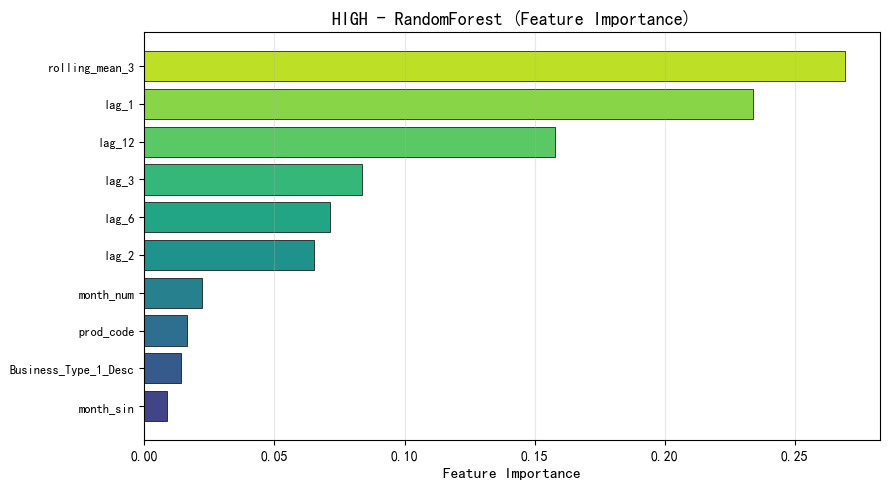


  [GBDT] Top 10 Feature Importance:
     1. rolling_mean_3                 0.4410
     2. lag_1                          0.2848
     3. lag_12                         0.1276
     4. lag_6                          0.0275
     5. price                          0.0252
     6. month_num                      0.0218
     7. month_sin                      0.0115
     8. lag_3                          0.0100
     9. time_idx                       0.0072
    10. lag_2                          0.0066


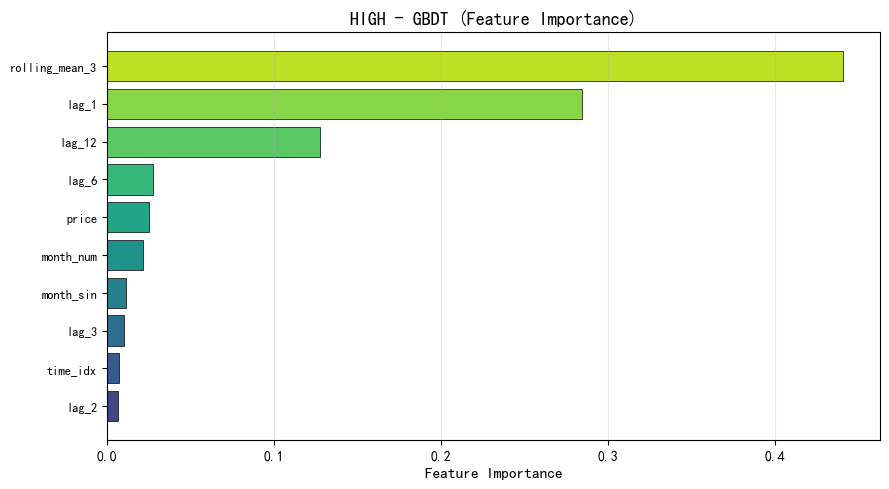


  [LightGBM] Top 10 Feature Importance:
     1. price                          1363.0000
     2. lag_12                         1305.0000
     3. month_num                      1202.0000
     4. lag_6                          982.0000
     5. lag_1                          919.0000
     6. rolling_mean_3                 904.0000
     7. year                           508.0000
     8. lag_3                          483.0000
     9. time_idx                       447.0000
    10. total_holiday_days             396.0000


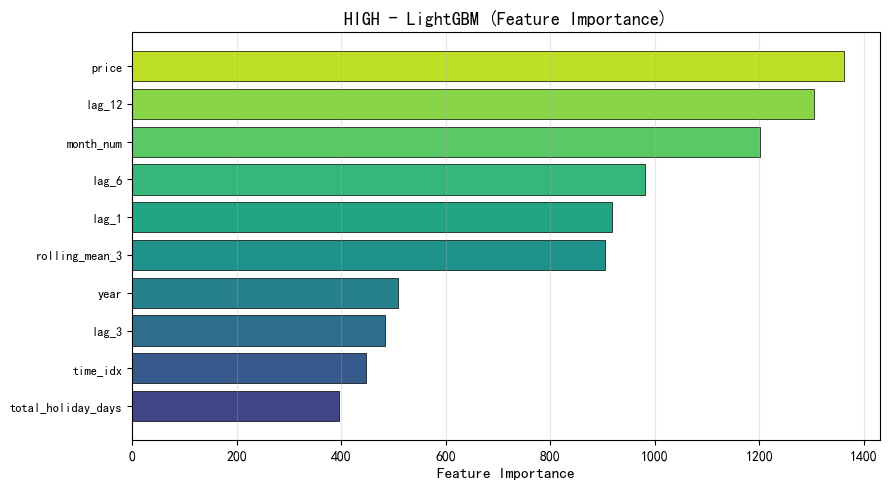


  [XGBoost] Top 10 Feature Importance:
     1. rolling_mean_3                 0.2704
     2. lag_1                          0.1903
     3. holiday_WomenDay_flag          0.0995
     4. holiday_NewYear_flag           0.0650
     5. lag_12                         0.0649
     6. month_num                      0.0324
     7. total_holiday_days             0.0239
     8. holiday_ChildrenDay_flag       0.0231
     9. month_sin                      0.0209
    10. quarter                        0.0207


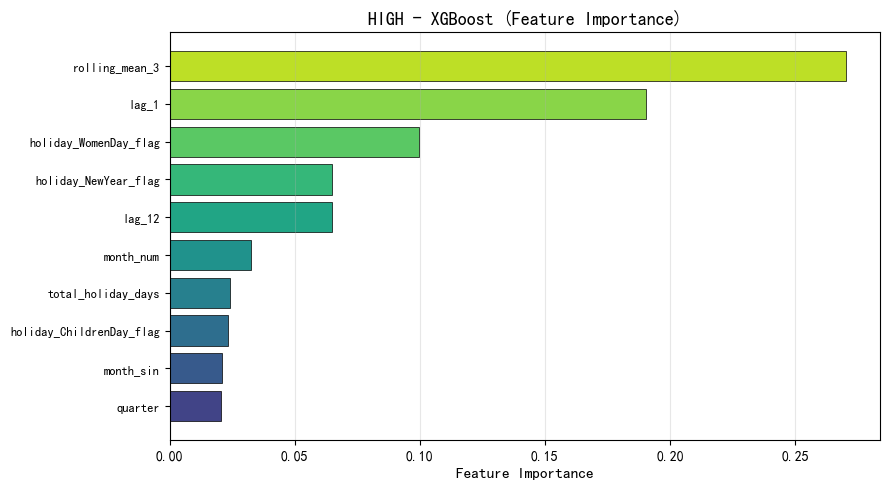


  [Ridge] Top 10 |Coefficient|:
     1. holiday_WomenDay_flag          148213.2435
     2. quarter                        130486.7639
     3. holiday_NewYear_flag           104274.9884
     4. holiday_ChildrenDay_flag       102900.6266
     5. month_num                      37403.5681
     6. holiday_NationalDay_flag       22753.2808
     7. holiday_LabourDay_flag         12858.1862
     8. Type_Group_Desc                8620.5861
     9. total_holiday_days             8479.8514
    10. Business_Type_1_Desc           6138.4725


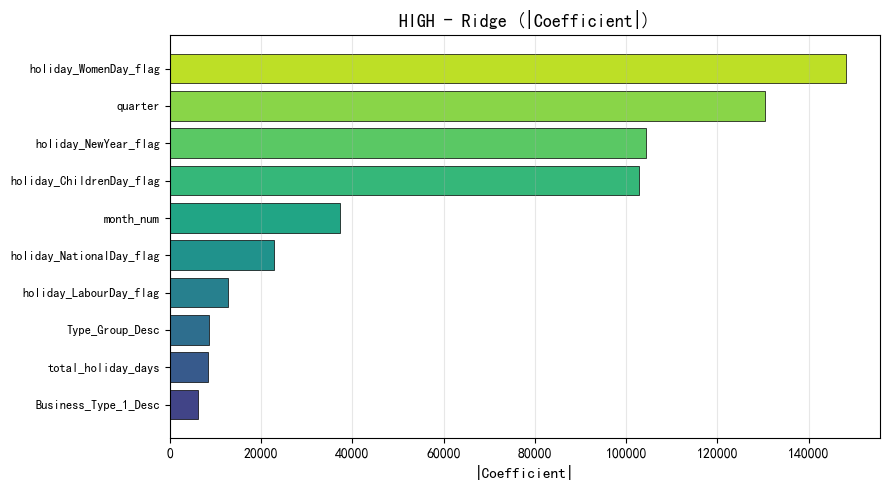


MEDIUM 组 - 模型特征重要性

  [RandomForest] Top 10 Feature Importance:
     1. rolling_mean_3                 0.3013
     2. lag_1                          0.2352
     3. lag_12                         0.1369
     4. lag_3                          0.0797
     5. lag_2                          0.0677
     6. lag_6                          0.0655
     7. month_num                      0.0250
     8. prod_code                      0.0123
     9. price                          0.0114
    10. Business_Type_1_Desc           0.0094


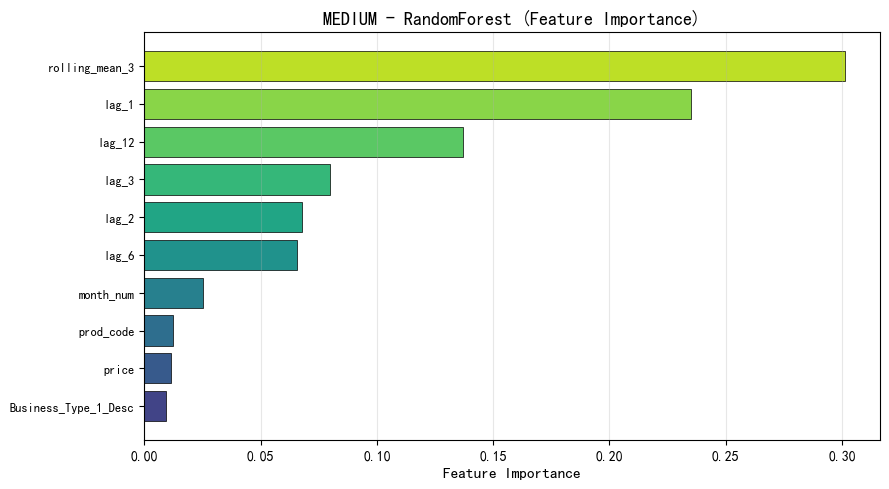


  [GBDT] Top 10 Feature Importance:
     1. rolling_mean_3                 0.5471
     2. lag_1                          0.1874
     3. lag_12                         0.0995
     4. month_num                      0.0376
     5. lag_6                          0.0363
     6. price                          0.0316
     7. month_sin                      0.0109
     8. time_idx                       0.0067
     9. lag_2                          0.0052
    10. lag_3                          0.0049


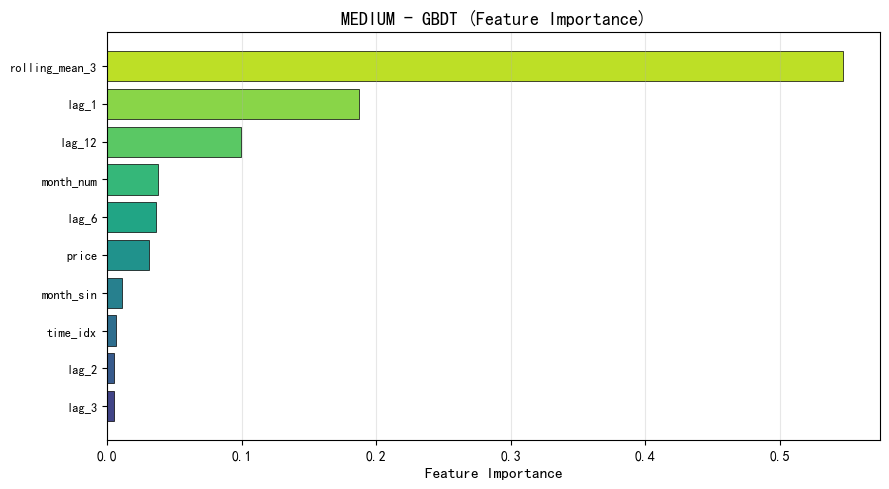


  [LightGBM] Top 10 Feature Importance:
     1. price                          1234.0000
     2. lag_12                         983.0000
     3. lag_1                          879.0000
     4. lag_6                          842.0000
     5. lag_3                          664.0000
     6. lag_2                          643.0000
     7. month_num                      642.0000
     8. time_idx                       631.0000
     9. rolling_mean_3                 618.0000
    10. store_code                     384.0000


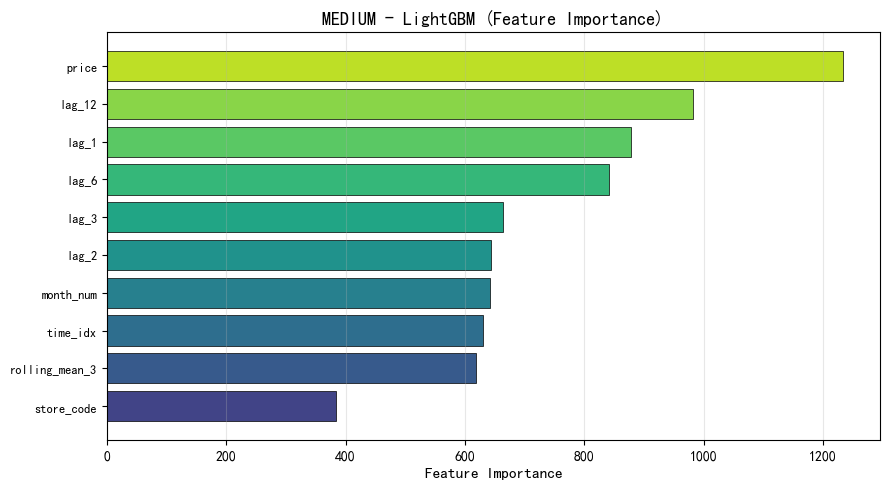


  [XGBoost] Top 10 Feature Importance:
     1. rolling_mean_3                 0.2384
     2. lag_1                          0.1952
     3. holiday_WomenDay_flag          0.1057
     4. lag_12                         0.0690
     5. quarter                        0.0348
     6. holiday_NewYear_flag           0.0324
     7. month_num                      0.0311
     8. Business_Type_1_Desc           0.0306
     9. lag_6                          0.0264
    10. Shop_Style_Desc                0.0245


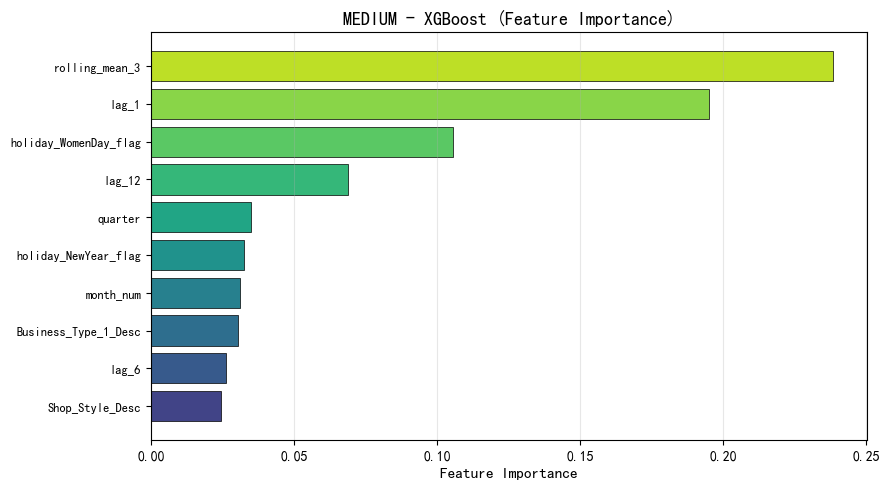


  [Ridge] Top 10 |Coefficient|:
     1. holiday_WomenDay_flag          123680.7454
     2. quarter                        92671.8611
     3. holiday_ChildrenDay_flag       68880.2634
     4. holiday_NewYear_flag           44298.4068
     5. holiday_NationalDay_flag       25128.3040
     6. month_num                      22643.9783
     7. month_cos                      8891.6139
     8. Business_Type_1_Desc           7901.0088
     9. Type_Group_Desc                7402.3093
    10. month_sin                      6766.1455


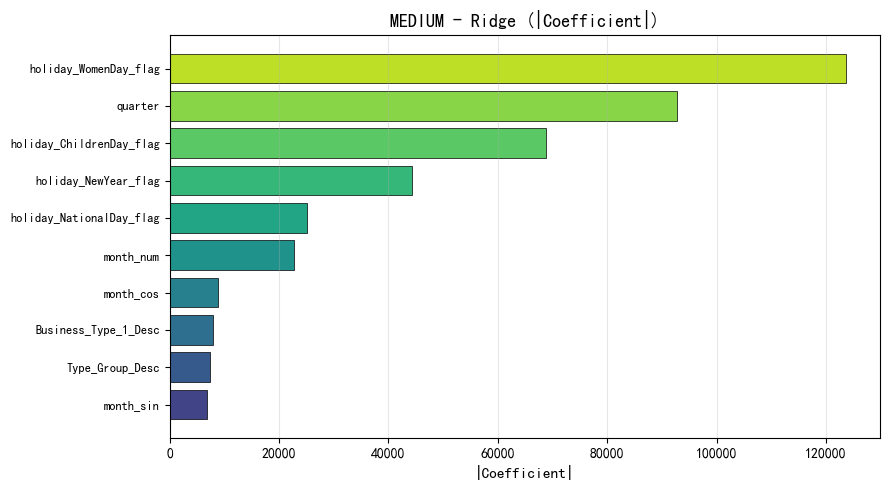


LOW 组 - 模型特征重要性

  [RandomForest] Top 10 Feature Importance:
     1. rolling_mean_3                 0.3240
     2. lag_1                          0.2381
     3. lag_12                         0.1297
     4. lag_2                          0.0934
     5. lag_3                          0.0643
     6. lag_6                          0.0547
     7. month_num                      0.0150
     8. prod_code                      0.0138
     9. month_cos                      0.0075
    10. price                          0.0075


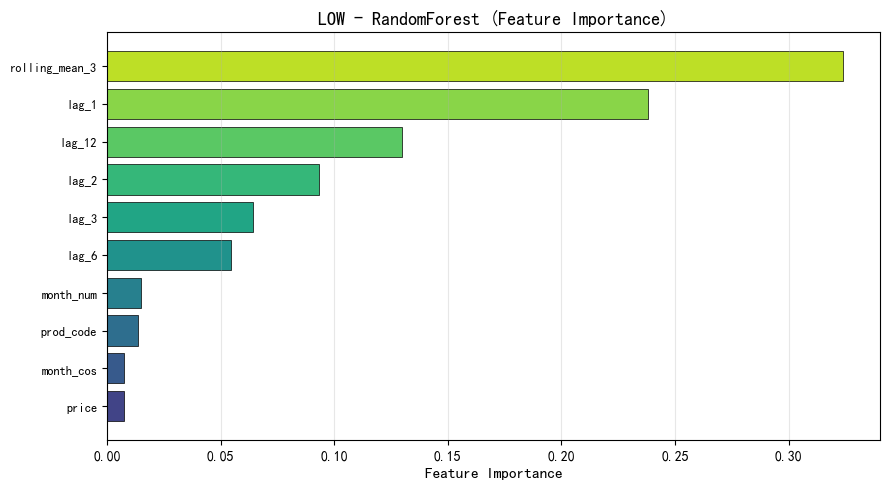


  [GBDT] Top 10 Feature Importance:
     1. rolling_mean_3                 0.6285
     2. lag_12                         0.1033
     3. lag_1                          0.0826
     4. lag_2                          0.0212
     5. lag_6                          0.0208
     6. price                          0.0207
     7. lag_3                          0.0188
     8. month_num                      0.0186
     9. time_idx                       0.0185
    10. month_cos                      0.0124


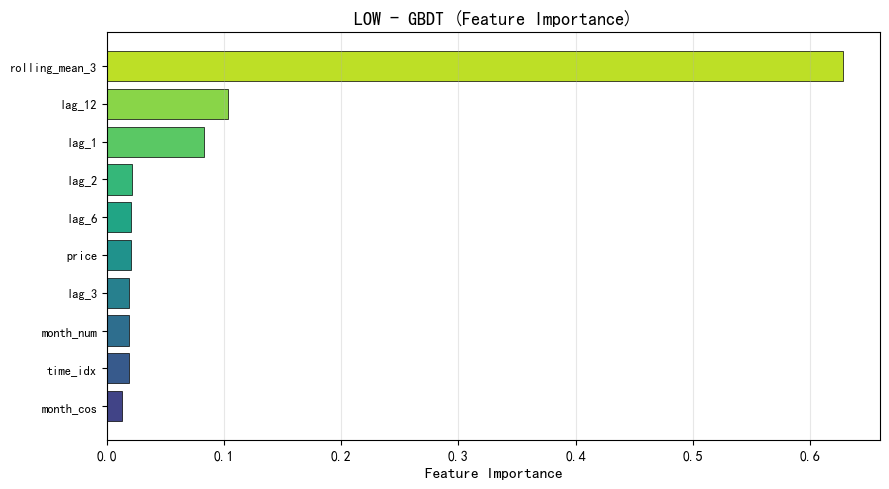


  [LightGBM] Top 10 Feature Importance:
     1. month_num                      258.0000
     2. lag_12                         244.0000
     3. price                          168.0000
     4. rolling_mean_3                 164.0000
     5. lag_1                          160.0000
     6. lag_6                          159.0000
     7. time_idx                       111.0000
     8. month_sin                      86.0000
     9. lag_2                          86.0000
    10. prod_code                      86.0000


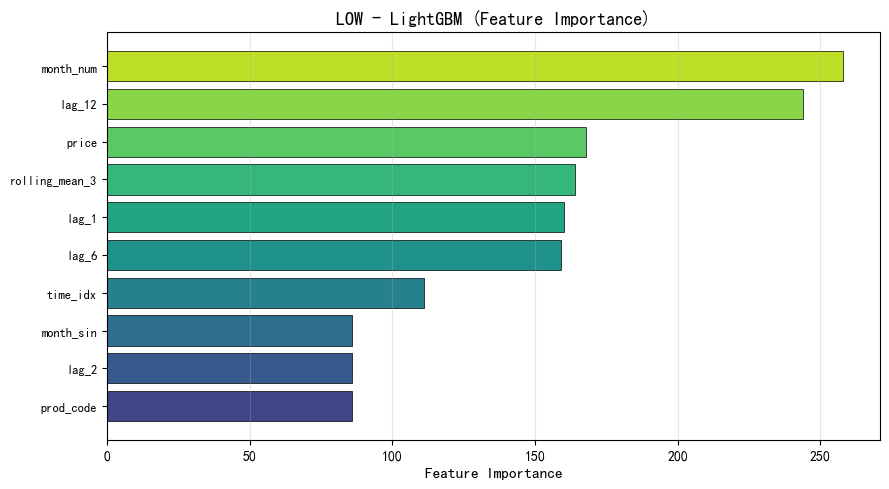


  [XGBoost] Top 10 Feature Importance:
     1. rolling_mean_3                 0.2508
     2. lag_1                          0.1477
     3. lag_12                         0.0652
     4. lag_2                          0.0540
     5. discrete_trend                 0.0492
     6. City_Level_Description         0.0248
     7. lag_6                          0.0238
     8. time_idx                       0.0233
     9. lag_3                          0.0228
    10. holiday_NewYear_flag           0.0221


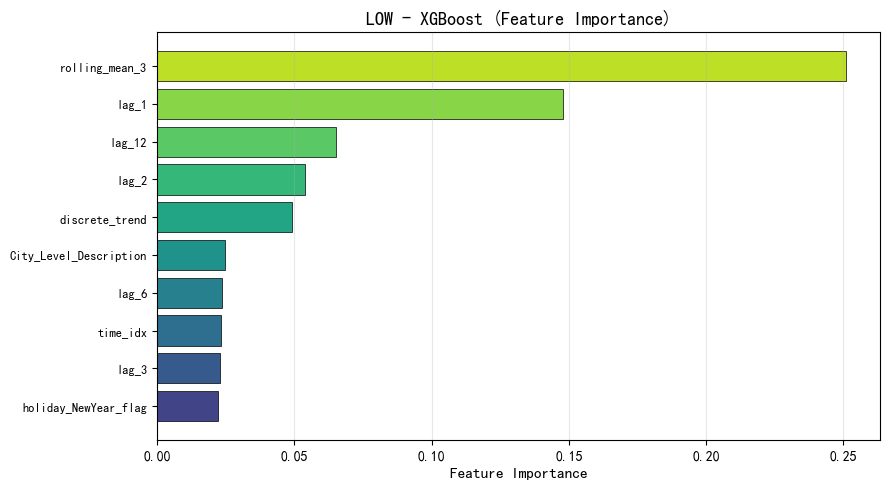


  [Ridge] Top 10 |Coefficient|:
     1. holiday_WomenDay_flag          25905.1875
     2. holiday_NewYear_flag           18957.5003
     3. quarter                        15767.1679
     4. holiday_ChildrenDay_flag       7486.8454
     5. month_cos                      4658.3752
     6. month_num                      3681.5608
     7. month_sin                      3177.5456
     8. holiday_LabourDay_flag         3144.9714
     9. Business_Type_1_Desc           2962.4092
    10. year                           2555.6918


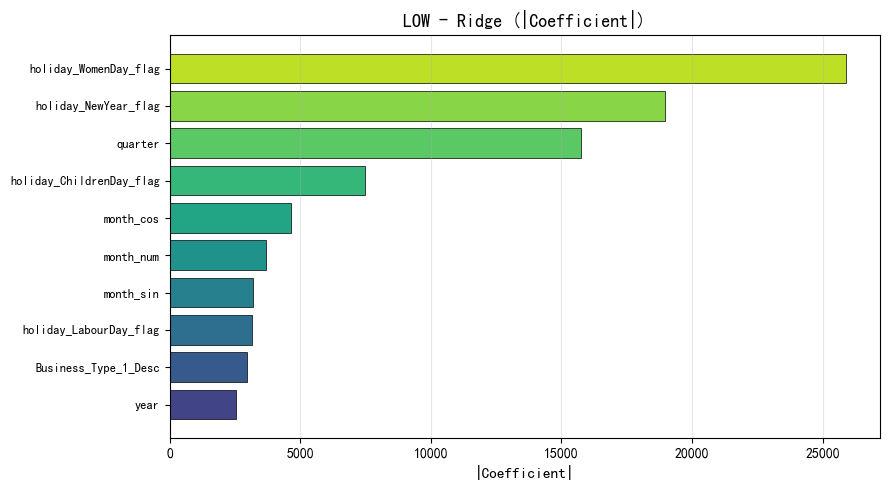


✅ 特征重要性可视化完成


In [35]:
# ==========================================
# 特征重要性可视化 (加载调参后模型)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("特征重要性可视化")
print("="*60)

# -------------------- 1. 加载调参后模型和特征名 --------------------
# 尝试加载树模型
try:
    with open('tuned_models.pkl', 'rb') as f:
        tuned_models = pickle.load(f)
    print("✅ 已加载 tuned_models.pkl")
    print(f"可用组: {list(tuned_models.keys())}")
    has_tuned = True
except FileNotFoundError:
    print("⚠️ tuned_models.pkl 未找到，尝试使用内存中的 models 字典")
    has_tuned = False

# 获取特征名 (从 processed_data_dict 或 X_train)
try:
    feat_names = processed_data_dict['high']['feat_names']
    print(f"从 processed_data_dict 获取特征名: {len(feat_names)} 个")
except (NameError, KeyError):
    try:
        feat_names = X_train.columns.tolist()
        print(f"从 X_train 获取特征名: {len(feat_names)} 个")
    except NameError:
        print("❌ 未找到特征名，请先运行特征工程 Cell (Cell 18)")
        feat_names = None

if feat_names is None:
    print("无法继续，请运行 Cell 18 后再试")
else:
    # -------------------- 2. 遍历各组各模型 --------------------
    groups = ['high', 'medium', 'low']
    
    for grp in groups:
        # 收集该组的模型
        group_models = {}
        
        # 从 tuned_models 获取树模型
        if has_tuned and grp in tuned_models:
            for model_name, model_info in tuned_models[grp].items():
                group_models[model_name] = model_info['model']
        
        # 从 models_non_tree 获取 Ridge (如果有)
        try:
            if (grp, 'Linear(Ridge)') in models_non_tree:
                group_models['Ridge'] = models_non_tree[(grp, 'Linear(Ridge)')]
        except NameError:
            pass
        
        if not group_models:
            print(f"\n{grp}: 无可用模型，跳过")
            continue
        
        print(f"\n{'='*60}")
        print(f"{grp.upper()} 组 - 模型特征重要性")
        print(f"{'='*60}")
        
        for model_name, model in group_models.items():
            try:
                # 获取重要性
                if hasattr(model, 'feature_importances_'):
                    importance = model.feature_importances_
                    imp_type = 'Feature Importance'
                elif hasattr(model, 'coef_'):
                    importance = np.abs(model.coef_).flatten()
                    imp_type = '|Coefficient|'
                else:
                    print(f"  {model_name}: 不支持特征重要性")
                    continue
                
                # 对齐长度
                n_features = min(len(importance), len(feat_names))
                imp_series = pd.Series(importance[:n_features], index=feat_names[:n_features])
                imp_series = imp_series.sort_values(ascending=False)
                
                print(f"\n  [{model_name}] Top 10 {imp_type}:")
                for i, (feat, val) in enumerate(imp_series.head(10).items()):
                    print(f"    {i+1:2d}. {feat:30s} {val:.4f}")
                
                # 绘图
                fig, ax = plt.subplots(figsize=(9, 5))
                top10 = imp_series.head(10)[::-1]
                colors = plt.cm.viridis(np.linspace(0.2, 0.9, 10))
                ax.barh(range(10), top10.values, color=colors, edgecolor='black', linewidth=0.5)
                ax.set_yticks(range(10))
                ax.set_yticklabels(top10.index, fontsize=9)
                ax.set_xlabel(imp_type, fontsize=11)
                ax.set_title(f"{grp.upper()} - {model_name} ({imp_type})", fontsize=13, fontweight='bold')
                ax.grid(True, alpha=0.3, axis='x')
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"  {model_name} 处理出错: {e}")

    print("\n✅ 特征重要性可视化完成")


效果对比可视化


预测效果可视化 - 随机抽样多组对比
✅ 已加载 tuned_models.pkl
✅ models_non_tree 可用

共加载 21 个模型
  [high] GBDT
  [high] LSTM
  [high] LightGBM
  [high] Linear(Ridge)
  [high] RandomForest
  [high] Transformer
  [high] XGBoost
  [low] GBDT
  [low] LSTM
  [low] LightGBM
  [low] Linear(Ridge)
  [low] RandomForest
  [low] Transformer
  [low] XGBoost
  [medium] GBDT
  [medium] LSTM
  [medium] LightGBM
  [medium] Linear(Ridge)
  [medium] RandomForest
  [medium] Transformer
  [medium] XGBoost

HIGH 组 - 随机序列预测可视化
    LSTM 预测失败: 'LSTMAttentionModel' object has no attribute 'predict'
    Transformer 预测失败: 'TransformerModel' object has no attribute 'predict'


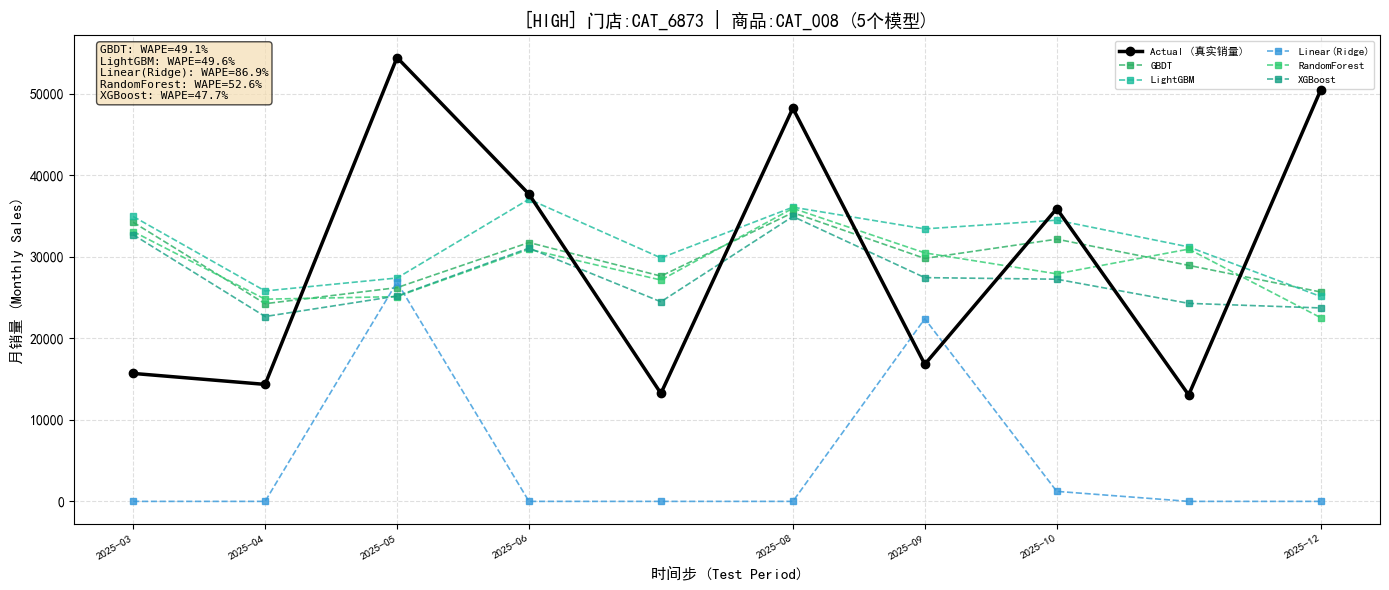

    LSTM 预测失败: 'LSTMAttentionModel' object has no attribute 'predict'
    Transformer 预测失败: 'TransformerModel' object has no attribute 'predict'


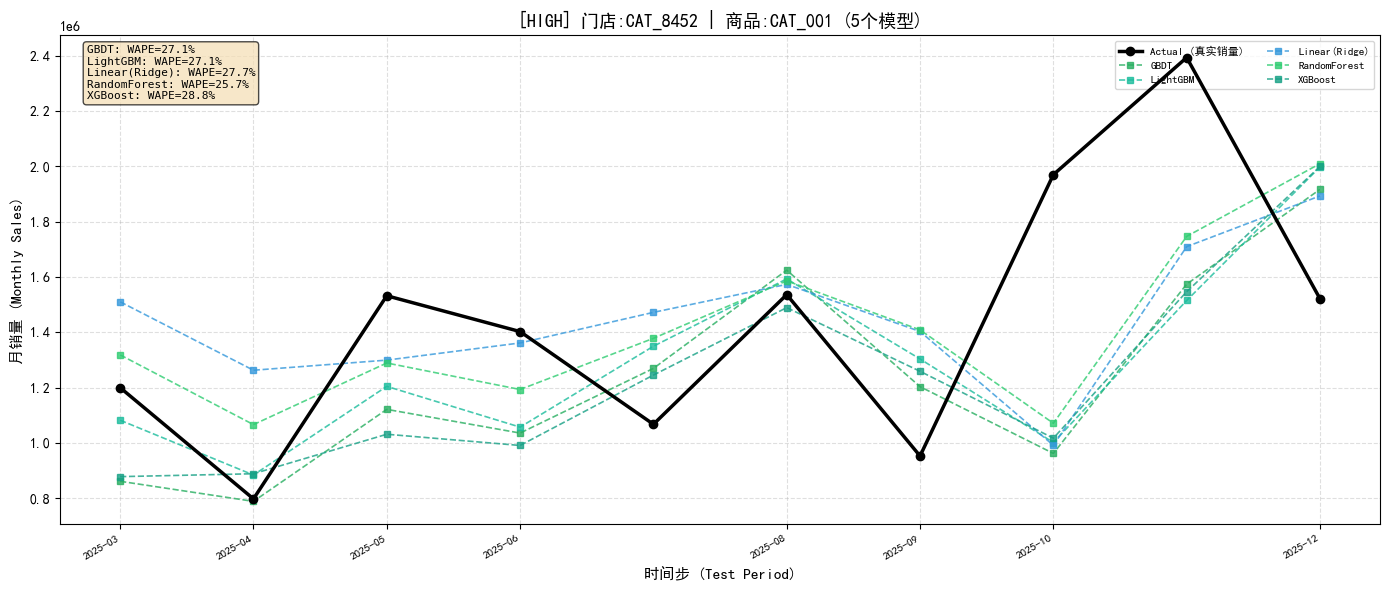


MEDIUM 组 - 随机序列预测可视化
    LSTM 预测失败: 'LSTMAttentionModel' object has no attribute 'predict'
    Transformer 预测失败: 'TransformerModel' object has no attribute 'predict'


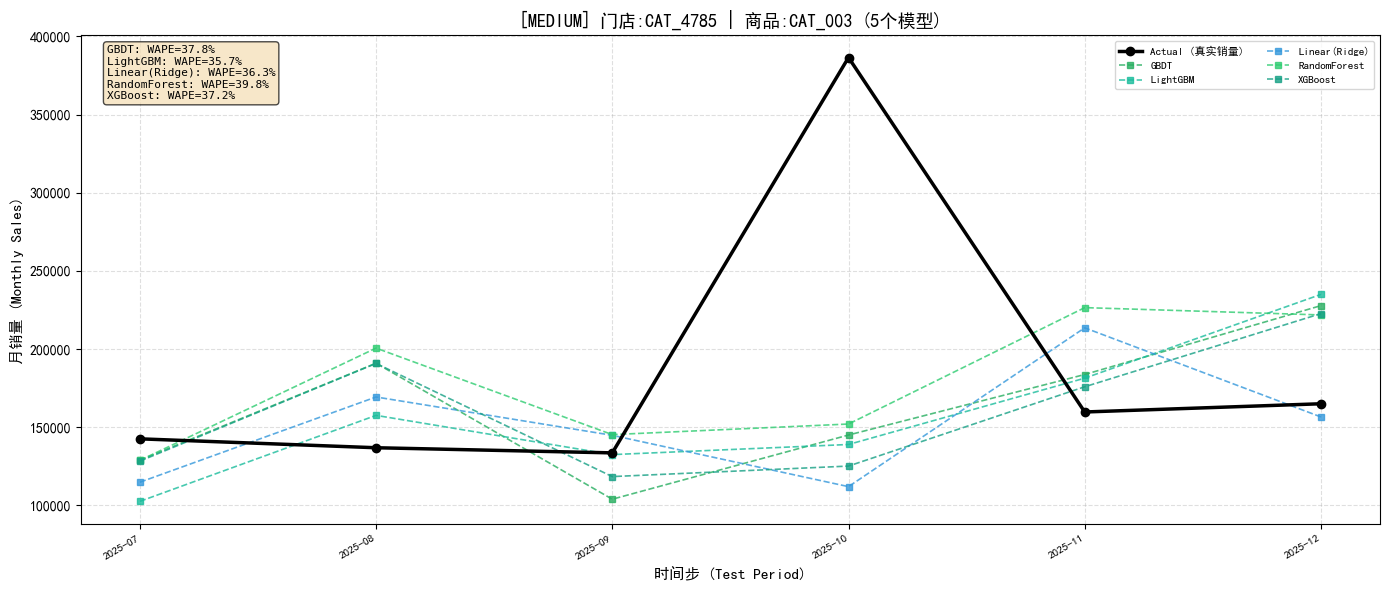

    LSTM 预测失败: 'LSTMAttentionModel' object has no attribute 'predict'
    Transformer 预测失败: 'TransformerModel' object has no attribute 'predict'


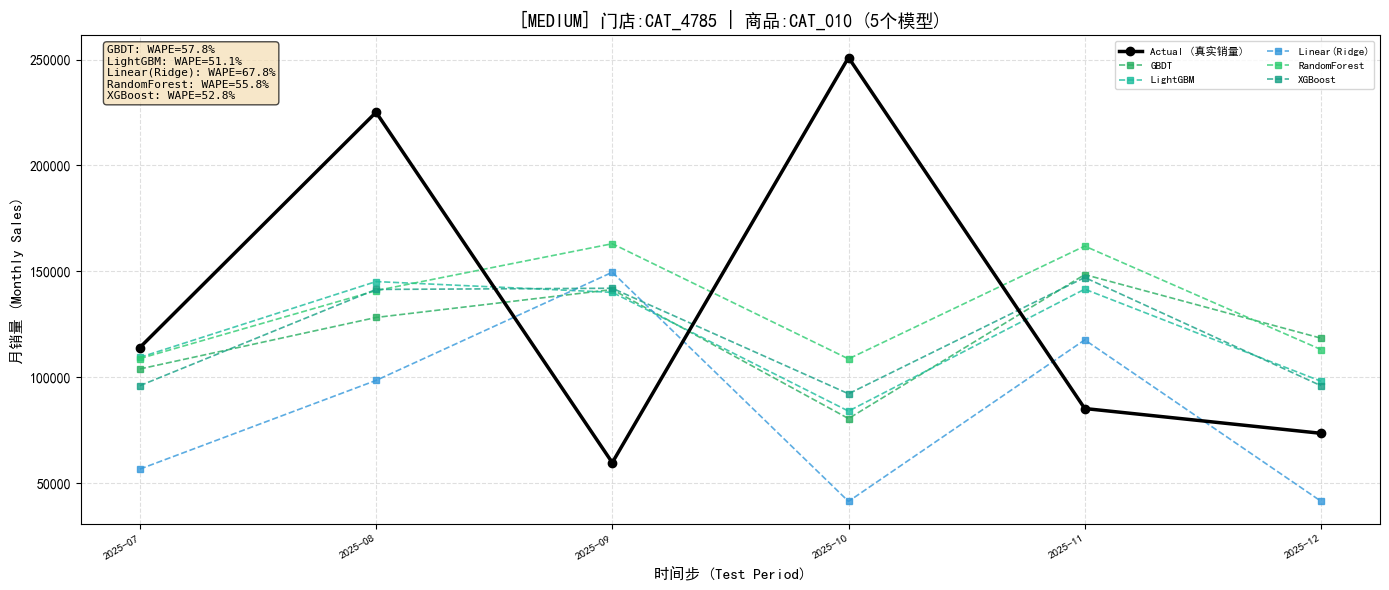


LOW 组 - 随机序列预测可视化
    LSTM 预测失败: 'LSTMAttentionModel' object has no attribute 'predict'
    Transformer 预测失败: 'TransformerModel' object has no attribute 'predict'


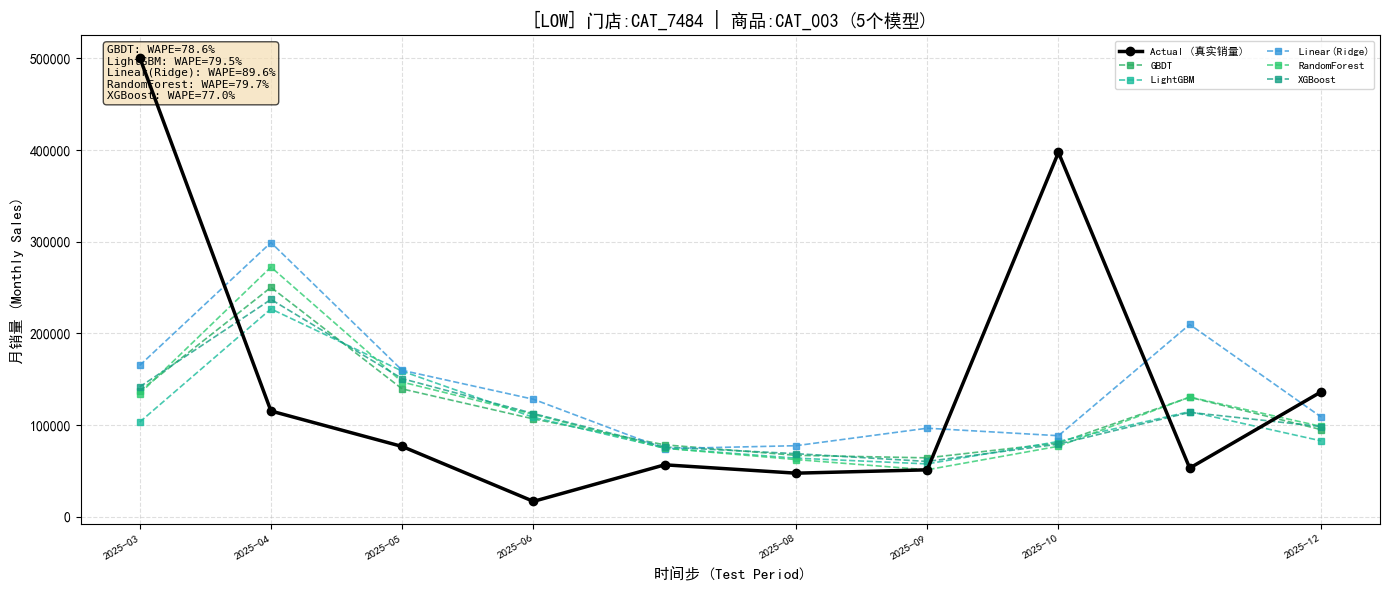

    LSTM 预测失败: 'LSTMAttentionModel' object has no attribute 'predict'
    Transformer 预测失败: 'TransformerModel' object has no attribute 'predict'


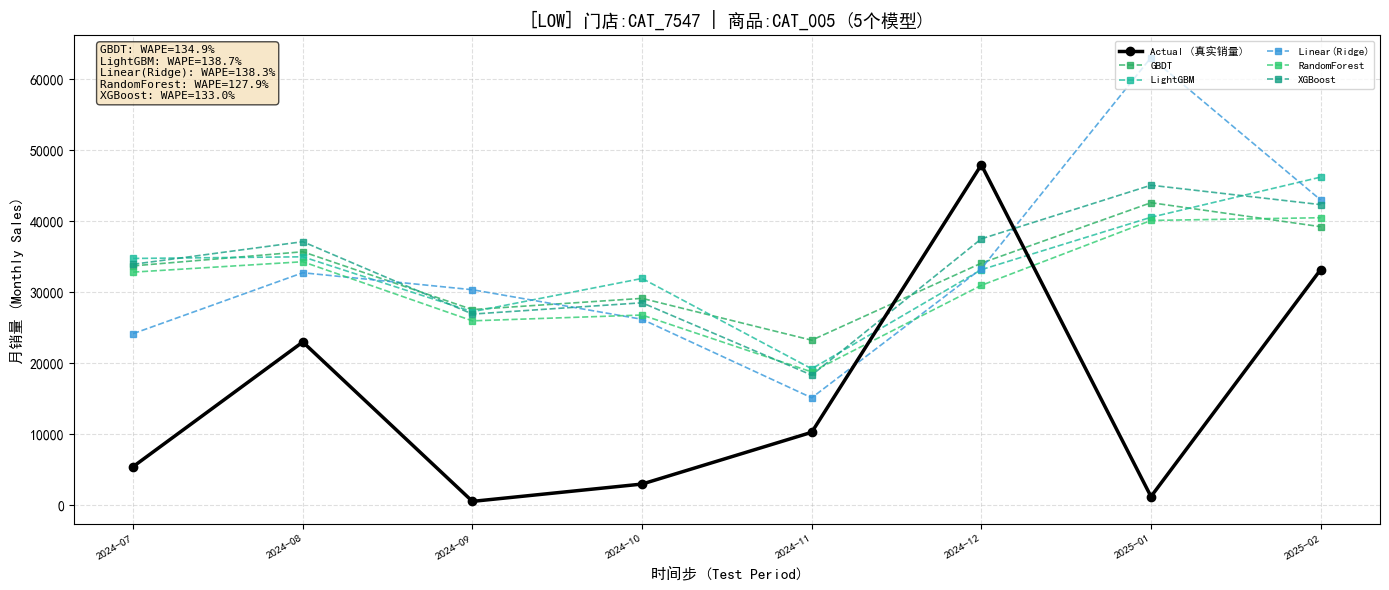


✅ 预测可视化完成


In [37]:
# ==========================================
# 预测效果可视化 (随机抽样，多组对比)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("\n" + "="*60)
print("预测效果可视化 - 随机抽样多组对比")
print("="*60)

# -------------------- 1. 加载模型 --------------------
# 加载树模型
try:
    with open('tuned_models.pkl', 'rb') as f:
        tuned_models = pickle.load(f)
    print("✅ 已加载 tuned_models.pkl")
except FileNotFoundError:
    tuned_models = {}
    print("⚠️ tuned_models.pkl 未找到")

# 尝试加载非树模型 (Ridge 等)
try:
    _ = models_non_tree
    print("✅ models_non_tree 可用")
except NameError:
    models_non_tree = {}
    print("⚠️ models_non_tree 不可用 (请先运行 Cell 24)")

# -------------------- 2. 构建统一的模型字典 --------------------
# 格式: {(group, model_name): model}
all_models = {}

for grp in ['high', 'medium', 'low']:
    # 树模型
    if grp in tuned_models:
        for model_name, model_info in tuned_models[grp].items():
            all_models[(grp, model_name)] = model_info['model']
    
    # 非树模型
    for (g, name), model in models_non_tree.items():
        if g == grp:
            all_models[(grp, name)] = model

print(f"\n共加载 {len(all_models)} 个模型")
for (grp, name) in sorted(all_models.keys()):
    print(f"  [{grp}] {name}")

# -------------------- 3. 随机抽样可视化 --------------------
groups = ['high', 'medium', 'low']
n_series_per_group = 2

# 模型颜色映射 (同类型同色系)
model_colors = {
    'RandomForest': '#2ecc71', 'GBDT': '#27ae60',
    'LightGBM': '#1abc9c', 'XGBoost': '#16a085',
    'Linear(Ridge)': '#3498db', 'Ridge': '#3498db',
    'LSTM': '#e67e22', 'Transformer': '#d35400',
    'Prophet': '#c0392b',
}

for grp in groups:
    print(f"\n{'='*60}")
    print(f"{grp.upper()} 组 - 随机序列预测可视化")
    print(f"{'='*60}")
    
    # 检查数据是否存在
    try:
        data = processed_data_dict[grp]
    except (NameError, KeyError):
        print(f"  ❌ processed_data_dict[{grp}] 不可用，请先运行 Cell 18")
        continue
    
    test_meta = data['test_meta']
    X_test_all = data['X_test']
    
    # 获取该组所有序列
    sequences = test_meta[['ref_branch_code', 'material_nature_sum_desc']].drop_duplicates().values
    if len(sequences) == 0:
        print(f"  {grp}: 无可用序列")
        continue
    
    selected = random.sample(list(sequences), min(n_series_per_group, len(sequences)))
    
    for store, prod in selected:
        seq_meta = test_meta[(test_meta['ref_branch_code'] == store) & 
                             (test_meta['material_nature_sum_desc'] == prod)].sort_values('month')
        valid_idx = seq_meta.index
        
        months = seq_meta['month']
        y_true = seq_meta['monthly_sales']
        X_test_seq = X_test_all.loc[valid_idx]
        
        # 获取该组的模型
        grp_models = {name: model for (g, name), model in all_models.items() if g == grp}
        
        if not grp_models:
            print(f"  {grp}: 无可用模型")
            continue
        
        # 绘图
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # 真实值 (加粗黑色实线)
        ax.plot(range(len(months)), y_true.values, 'o-',
                label='Actual (真实销量)', linewidth=2.5, color='black', zorder=10, markersize=6)
        
        # 各模型预测
        model_count = 0
        for model_name, model in sorted(grp_models.items()):
            try:
                y_pred = model.predict(X_test_seq)
                y_pred = np.maximum(0, y_pred)
                color = model_colors.get(model_name, '#95a5a6')
                ax.plot(range(len(months)), y_pred, 's--',
                        label=model_name, alpha=0.8, linewidth=1.2, color=color, markersize=4)
                model_count += 1
            except Exception as e:
                print(f"    {model_name} 预测失败: {e}")
        
        # 计算每个模型的 WAPE 并标注
        def wape(y_true, y_pred):
            return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
        
        wape_text_lines = []
        for model_name, model in sorted(grp_models.items()):
            try:
                y_pred = np.maximum(0, model.predict(X_test_seq))
                w = wape(y_true.values, y_pred)
                wape_text_lines.append(f'{model_name}: WAPE={w:.1f}%')
            except Exception:
                pass
        
        if wape_text_lines:
            wape_text = '\n'.join(wape_text_lines)
            ax.text(0.02, 0.98, wape_text, transform=ax.transAxes,
                    fontsize=8, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
        
        # 装饰
        ax.set_xlabel('时间步 (Test Period)', fontsize=11)
        ax.set_ylabel('月销量 (Monthly Sales)', fontsize=11)
        prod_str = str(prod)[:30]
        store_str = str(store)[:20]
        ax.set_title(f"[{grp.upper()}] 门店:{store_str} | 商品:{prod_str} ({model_count}个模型)",
                     fontsize=13, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8, ncol=2)
        ax.grid(True, linestyle='--', alpha=0.4)
        
        # x轴标签用月份
        n_ticks = min(8, len(months))
        tick_positions = np.linspace(0, len(months)-1, n_ticks, dtype=int)
        tick_labels = [months.iloc[i].strftime('%Y-%m') if hasattr(months.iloc[i], 'strftime') else str(months.iloc[i])[:7] for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)
        
        plt.tight_layout()
        plt.show()

print("\n✅ 预测可视化完成")
# 如果 all_models 为空，给出提示
if len(all_models) == 0:
    print("\n⚠️ 未加载到任何模型！")
    print("请确保已运行以下 Cell:")
    print("  - Cell 22 (Optuna调参) → 生成 tuned_models.pkl")
    print("  - Cell 24 (非树模型) → 填充 models_non_tree")
    print("  - Cell 18 (特征工程) → 生成 processed_data_dict")
